# Neural network reserving models against classical benchmarks

We compare four neural network reserving models with two classical benchmarks on a
one-year-ahead forecasting task. Each model is fit to the paid loss triangle as observed at
year-end 1997 and evaluated on the development realized during calendar year 1998. The
comparison runs on a panel, in the econometric sense of the word: a fixed set of
company-line cohorts, selected once, on which every model is fit and scored. Fixing it is
what makes the board readable, because every number on it then comes from the same cohorts
and the same cells. This panel comprises ten insurers passing the screens of the Meyers
monograph on at least two lines of business, twenty-five company-line cohorts in all.

The data are NAIC Schedule P triangles from the CAS loss reserving database: accident years
1990 through 1997, valued at 31 December 1997. To the Meyers screens we add a positivity
condition on paid increments, described in the panel section below. The comparison has three
parts:

* the four neural entries - `nn_transformer`, `mdn`, `resnet` and `deeptriangle` - against
  Mack's distribution-free chain ladder on the next calendar diagonal, scored by the
  continuous ranked probability score (CRPS), by premium-normalized point error against
  realized ultimates, and by the probability integral transform (PIT) of the realized
  outcomes;
* the same methods at the ultimate level on two fields, paid and incurred, with Zhang's
  seemingly-unrelated-regressions multivariate chain ladder fitted on both, and three
  further paid rows from the case-reserve work in ibnr 0.5.5;
* and the cross-line dependence that entry estimates, which nothing else here models.

Each model is reached through the same sequence of calls:

```
gallery.fit(name, triangle, ...)          # a fitted GalleryEntry
  -> entry.log_lik_at(cells, field=...)   # ScoresHeldout  -> (draws, cells) log densities
  -> entry.predict_at(cells, field=...)   # PredictsHeldout -> (draws, cells) loss draws
  -> gallery.align_panel(...)             # one identical cell set per score
  -> gallery.leaderboard(panel)           # the board
```

## Reproducibility

The notebook runs from any working directory: every number below comes from a live fit,
and every path is resolved by the library from its own cache.

Requirements are Python 3.11 or 3.12 and
`pip install "ibnr[nn]==0.5.5" cas-schedule-p==2026.6.13 matplotlib`. Both versions are
pinned and asserted in the cells that follow: the transformer section reads internals of
ibnr 0.5.5, and the company screens install with the `cas-schedule-p` package, which names
the data publish every result below is asserted against. The triangle source is pinned to
gold publish `20260613_041006`.

Installing is the only step that needs the network. The `cas-schedule-p` wheel carries the
whole gold publish, and the seeding cell below copies it into the directory ibnr's loader
reads, so the data load itself is offline. Without the seeding cell - the ordinary
case for a user of the library - ibnr 0.5.5 fetches the release assets from the public data
repository over plain HTTPS. Total runtime is about seven minutes.

In [1]:
# %pip install "ibnr[nn]==0.5.5" cas-schedule-p==2026.6.13 matplotlib

import datetime as dt
import platform
import sys
import time
import warnings

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, display

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery import (
    SCORE_DIRECTION,
    Absence,
    CohortForecast,
    align_panel,
    next_diagonal,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels.calibration import ks_uniformity, pp_points

# What the version pin carries. The transformer section below reads modules that are not
# public API - the neural data contract, the training scheme, the network class - as they
# stand in this exact release. The panel assert further down pins a data publish.
assert ibnr.__version__ == "0.5.5", (
    f"this notebook is pinned to ibnr 0.5.5 and found {ibnr.__version__}. "
    'Install the exact version:  pip install "ibnr[nn]==0.5.5" '
    "cas-schedule-p==2026.6.13 matplotlib"
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

T_START = time.perf_counter()  # the wall clock the closing cell reports

# --- the one cutoff, the one field ------------------------------------------
AS_OF = dt.date(1997, 12, 31)
FIELD = "paid_loss"
TASK = f"{FIELD}@1997"
PREMIUM_FIELD = "earned_premium"
# THE STUDY WINDOW. The triangle itself is cut to these accident years before
# anything is fitted, so every fit and every held-out cell rest on the same
# data. Accident years 1988 and 1989 are out of the study entirely; they are
# not merely left unscored.
ORIGINS = [dt.date(y, 1, 1) for y in range(1990, 1998)]
SEED_FIT = 11  # every torch init
SEED_DRAW = 7  # every predict_at() and predict() call

print("ibnr  ", ibnr.__version__)
print("python", sys.version.split()[0], platform.platform())

ibnr   0.5.5
python 3.12.13 Windows-11-10.0.26200-SP0


## Data source

The panel is built from a CAS Schedule P gold mart, which the package consumes as an
immutable GitHub release: one release per gold publish, tagged with its publish id and
carrying a manifest of sha256 sums.

The loader caches the release under `~/.cache/ibnr` (or `IBNR_CACHE_DIR` if it is set) and
reads a pinned tag from disk. The seeding cell below fills that cache from the
`cas-schedule-p` wheel, which carries this publish.

The tag is a concrete publish id rather than a floating pointer, for two reasons. A floating
tag has to be resolved against the GitHub API on every run, even when the data are already
cached; and the panel assertion below is a claim about one specific publish.
`active_publish_id` re-reads the cached manifest. All four data calls below are handed the
same pinned string.

In [2]:
# --- seed ibnr's download cache from the installed data package --------------
# The cas-schedule-p wheel already carries this gold publish - sixteen parquet tables plus
# manifest.json - so copying those files where ibnr's loader looks turns every data call
# below into a local file read. Skip this cell and the loader downloads the same files
# over anonymous HTTPS instead.
#
# The layout is ibnr's own, read off ibnr/data/schedule_p.py:_cache_dir - IBNR_CACHE_DIR
# (or ~/.cache/ibnr) / "<owner>__<repo>" / "<publish_id>" - and manifest.json is the file
# it tests for a warm cache. The publish seeded is the wheel's own; the next cell pins the
# same string in SOURCE, and the screens cell asserts that the two agree.
import os
import shutil
from pathlib import Path

import cas_schedule_p

_cache_root = os.environ.get("IBNR_CACHE_DIR")
CACHE_DIR = (
    (Path(_cache_root) if _cache_root else Path.home() / ".cache" / "ibnr")
    / cas_schedule_p.REPO.replace("/", "__")
    / cas_schedule_p.PUBLISH_ID
)

if (CACHE_DIR / "manifest.json").exists():
    print(f"cache already holds publish {cas_schedule_p.PUBLISH_ID}: {CACHE_DIR}")
else:
    _entries = cas_schedule_p.manifest()["tables"]
    _bundled = [cas_schedule_p.path(t) for t in cas_schedule_p.tables()]
    # manifest.json sits beside the parquet files and is copied LAST, so an interrupted
    # seed cannot leave a cache that reads as complete; each file lands under a temp name
    # and is renamed into place for the same reason.
    _bundled.append(_bundled[0].parent / "manifest.json")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for _src in _bundled:
        _dest = CACHE_DIR / _src.name
        _tmp = _dest.with_name(_dest.name + ".part")
        shutil.copyfile(_src, _tmp)
        os.replace(_tmp, _dest)
    # the size test the loader itself applies to an already-cached asset
    assert all((CACHE_DIR / e["asset"]).stat().st_size == e["bytes"] for e in _entries.values())
    print(f"seeded {len(_bundled)} files into {CACHE_DIR}")

seeded 17 files into C:\Users\ETHANK~1\AppData\Local\Temp\claude\C--Users-EthanKang-Projects-ibnr\c4a17f6b-bfe0-494d-8af9-eb552f01b742\scratchpad\ibnr_cache_cold\EKtheSage__cas-schedule-p-data-model\20260613_041006


In [3]:
# --- provenance -------------------------------------------------------------
SOURCE = pinned_source("github://EKtheSage/cas-schedule-p-data-model@20260613_041006")
PUBLISH_ID = active_publish_id(SOURCE)
assert PUBLISH_ID == "20260613_041006", PUBLISH_ID

MART = active_mart_path(SOURCE)
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", MART.name)

mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet


## Data and panel selection

A screen is a fixed, mechanical set of criteria deciding which companies enter the study.
The same screens run for every model, so a difference on the board comes from the models
and never from which companies each was allowed to see. Two screens apply, both re-derived
below from the mart.

1. **The Meyers screens** (Meyers, *Stochastic Loss Reserving Using Bayesian MCMC Models*,
   CAS Monograph Series Number 1, Table A.1): the coefficient of variation of net earned
   premium, the coefficient of variation of the net-to-direct premium ratio, a complete
   10x10 square, a premium floor, a loss floor, and one excluded group. Run over all four
   lines they pass 60 companies on two or more lines, 152 (company, line) pairs in all.

2. **A positivity condition on paid increments.** A cohort survives only if no paid
   increment anywhere in its training history is negative. Ten companies are clean on every
   one of their screened lines, and the twenty-five cohorts those companies contribute are
   the published panel. The condition is stated once, on the panel, so every model on the
   board is scored on the same cohorts.

The size range is wide: over the study window the largest cohort carries about twelve
million (USD thousands) of mean earned premium and the smallest a couple of hundred, so the
comparison is not a study of one magnitude.

The screens are imported from `cas_schedule_p.screens`, the package published by the project
that publishes the gold mart. The screen constants, the screening SQL and the parquet are one
release artifact carrying one version number, so a published cohort is reproducible from two
pins: the package version and the mart's publish id. The next cell asserts that the package's
`PUBLISH_ID` is the publish this notebook loaded. This notebook hands `select_companies` the
same cached parquet every other data call uses, so the whole notebook stays on one file.

In [4]:
# The Meyers screen (the monograph's Table A.1), from the data's own package.
import cas_schedule_p
from cas_schedule_p import screens
from cas_schedule_p.screens import MEYERS_LINES, select_companies

assert cas_schedule_p.__version__ == "2026.6.13", (
    f"this notebook is pinned to cas-schedule-p 2026.6.13 and found {cas_schedule_p.__version__}"
)
# The screen and the mart must come from the SAME gold publish.
assert cas_schedule_p.PUBLISH_ID == PUBLISH_ID, (cas_schedule_p.PUBLISH_ID, PUBLISH_ID)
# And the cutoff the screen is written against is this notebook's AS_OF.
assert AS_OF.isoformat() == screens.AS_OF, (screens.AS_OF, AS_OF)

In [5]:
t0 = time.perf_counter()
passing = {ln: set(select_companies(MART, ln, 10_000)["company_code"]) for ln in MEYERS_LINES}
by_company: dict[str, list[str]] = {}
for ln, codes in passing.items():
    for c in codes:
        by_company.setdefault(c, []).append(ln)
multiline = {c: sorted(ls) for c, ls in by_company.items() if len(ls) >= 2}
print({ln: len(v) for ln, v in passing.items()})
print(
    f"companies passing on >=2 lines: {len(multiline)}  pairs: {sum(map(len, multiline.values()))}"
)

# --- positivity screen on the <=1997 training slice ---------------------------
# Applied over the FULL 1988-1997 history rather than the study window below.
# It is strictly conservative - a cohort with no negative paid increment over
# ten accident years has none over the eight the study keeps - and running it
# on the wider history is what keeps this panel identical to the published
# panel, so the two are comparable cohort for cohort.
scan = load_schedule_p(SOURCE, lines=MEYERS_LINES, companies=sorted(multiline)).expr.execute()
scan["eval_date"] = pd.to_datetime(scan["eval_date"])
scan["origin_period"] = pd.to_datetime(scan["origin_period"])
paid_train = scan[
    (scan["field"] == FIELD)
    & (scan["eval_date"] <= pd.Timestamp(AS_OF))
    & (scan["origin_period"].dt.year.between(1988, 1997))
]
clean_pairs = set()
for key, g in paid_train.groupby(["company_code", "line_of_business"]):
    increments = [
        np.diff(np.r_[0.0, gg.sort_values("dev_lag")["value"].to_numpy()])
        for _, gg in g.groupby("origin_period")
    ]
    if all((inc >= 0).all() for inc in increments):
        clean_pairs.add(key)
print(f"pairs with no negative paid increment in the training slice: {len(clean_pairs)}")

PANEL = {c: ls for c, ls in sorted(multiline.items()) if all((c, ln) in clean_pairs for ln in ls)}
COHORTS = [(c, ln) for c, ls in PANEL.items() for ln in ls]
LINES = sorted({ln for ls in PANEL.values() for ln in ls})
print(f"screens took {time.perf_counter() - t0:.1f}s")

# Recorded: if a future gold publish moves the panel, this assert catches it before
# the comparison runs. The second lock on provenance; the pinned publish id is the first.
EXPECTED_PANEL = {
    "10022": ["commercial_auto", "private_passenger_auto"],
    "14044": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "1767": [
        "commercial_auto",
        "other_liability",
        "private_passenger_auto",
        "workers_compensation",
    ],
    "18767": ["commercial_auto", "workers_compensation"],
    "2003": ["other_liability", "private_passenger_auto"],
    "25275": ["commercial_auto", "private_passenger_auto"],
    "27022": ["commercial_auto", "private_passenger_auto"],
    "2712": ["commercial_auto", "workers_compensation"],
    "620": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "7080": ["commercial_auto", "private_passenger_auto", "workers_compensation"],
}
assert PANEL == EXPECTED_PANEL, f"panel moved under publish_id {PUBLISH_ID}: {PANEL}"
print(f"\n{len(PANEL)} companies, {len(COHORTS)} cohorts, {len(LINES)} lines")
for c, ls in PANEL.items():
    print(f"  {c:>6}  {', '.join(ls)}")

{'commercial_auto': 63, 'private_passenger_auto': 60, 'workers_compensation': 52, 'other_liability': 56}
companies passing on >=2 lines: 60  pairs: 152


pairs with no negative paid increment in the training slice: 87
screens took 4.9s

10 companies, 25 cohorts, 4 lines
   10022  commercial_auto, private_passenger_auto
   14044  commercial_auto, other_liability, private_passenger_auto
    1767  commercial_auto, other_liability, private_passenger_auto, workers_compensation
   18767  commercial_auto, workers_compensation
    2003  other_liability, private_passenger_auto
   25275  commercial_auto, private_passenger_auto
   27022  commercial_auto, private_passenger_auto
    2712  commercial_auto, workers_compensation
     620  commercial_auto, other_liability, private_passenger_auto
    7080  commercial_auto, private_passenger_auto, workers_compensation


### The study window

The mart carries accident years 1988-2007; the study window is 1990-1997. The restriction
is applied once, to the triangle itself: `tri` holds only the study years, and everything
downstream - every fit, every call to `next_diagonal`, every realized ultimate - reads
`tri`. A single restricted table is what guarantees the fits and the held-out census agree
on what the training data were.

In [6]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=list(PANEL), lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep only the
# 25 screened pairs.
_e = tri_all.expr
_keep = ibis.literal(False)
for c, ls in PANEL.items():
    for ln in ls:
        _keep = _keep | ((_e.company_code == c) & (_e.line_of_business == ln))
tri_full = tri_all.filter(_keep)

# The mart's display segment is dropped. The mart carries three segments; the neural
# data contract treats company_name as display-only, so a pooled NN fit is keyed on two.
# Dropping the column here keeps every path on one schema.
tri_full = tri_full.with_expr(tri_full.expr.drop("company_name"))

tri = tri_full.filter(tri_full.expr.origin_period.isin(ORIGINS))
print("segments:", tri.segments)
print(f"{tri_full.count()} rows loaded in {time.perf_counter() - t0:.1f}s")
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)
print(
    f"{tri.count()} rows inside the study window: accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year} ({len(ORIGINS)} of them)"
)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_paid_latest = _frame[
    (_frame["field"] == FIELD) & (pd.to_datetime(_frame["eval_date"]) == pd.Timestamp(AS_OF))
]
# Total earned premium over the window, per cohort - the denominator the ultimate-level
# sections normalize reserve errors by, so a $2M book and a $2B book are comparable.
# The mart books an origin's earned premium at every development age that origin carries,
# so summing the rows counts each origin's premium once per age. The premium is taken once
# per origin instead, and the assert is that the repeated rows agree.
_prem_by_origin = _prem.groupby(["company_code", "line_of_business", "origin_period"])["value"]
assert (_prem_by_origin.nunique() == 1).all()
PREMIUM_TOTAL = (
    _prem_by_origin.first().groupby(["company_code", "line_of_business"]).sum().to_dict()
)
pairs_table = (
    _prem.groupby(["company_code", "line_of_business"])["value"]
    .mean()
    .rename("mean_earned_premium")
    .to_frame()
    .join(
        _paid_latest.groupby(["company_code", "line_of_business"])["value"]
        .sum()
        .rename("paid_at_1997")
    )
    .reset_index()
    .sort_values("mean_earned_premium", ascending=False)
    .reset_index(drop=True)
)
print("\nunits:", tri.meta.units)
pairs_table.round(0)

segments: ['company_code', 'line_of_business']


35000 rows loaded in 0.2s


14000 rows inside the study window: accident years 1990-1997 (8 of them)

units: USD thousands


,company_code,line_of_business,mean_earned_premium,paid_at_1997
0,1767,private_passenger_auto,12635198.0,65271145.0
1,2003,private_passenger_auto,1897574.0,8778907.0
2,1767,commercial_auto,368564.0,1479179.0
3,1767,workers_compensation,315899.0,1162383.0
4,7080,workers_compensation,291281.0,1147580.0
5,1767,other_liability,264061.0,1150600.0
6,7080,private_passenger_auto,205590.0,805616.0
7,2712,workers_compensation,90936.0,351754.0
8,620,other_liability,77036.0,228301.0
9,2003,other_liability,71516.0,127602.0


## Held-out cells

`next_diagonal(triangle, as_of=..., fields=...)` answers one question: given a fit trained on
everything visible at `as_of`, which cells is it scored on? The answer is the next calendar
diagonal, one cohort at a time, with the next development lag read from the data. Cells the
fit could not have known about are excluded and counted by reason (`new_origin`,
`dev_beyond_trained`, and so on).

Two choices are worth stating.

**Cells are built for both `paid_loss` and `reported_loss`, although the board is on paid.**
No entry on this board consumes the second field. It is kept because the `HoldoutCells`
objects are part of the panel's identity: the second field contributes its own exclusion
census, and building the cells this way keeps the panel's fingerprint comparable with the
published one. So `n_cells` reads 14 per cohort while the paid narrowing gives 7.

**There is no `origins=` argument, because the triangle is already the study window.**
`next_diagonal` accepts one, but it restricts the training claims the census is computed
from as well as the cells to be scored, so the returned `HoldoutCells` would describe a
training window narrower than the one the fits consumed. `HoldoutCells.train_origins` is
asserted below against `ORIGINS` for all twenty-five cohorts.

That leaves 7 held-out paid cells per cohort, 175 offered in total. How many of them a score
rests on is decided later, by the intersection over that score's own members.

In [7]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for c, ln in COHORTS:
    s = tri.filter((tri.expr.company_code == c) & (tri.expr.line_of_business == ln))
    sub[(c, ln)] = s
    cells[(c, ln)] = next_diagonal(
        s,
        as_of=AS_OF,
        # both fields, matching the published census, so the panel
        # fingerprints and exclusion counts stay comparable
        fields=[FIELD, "reported_loss"],
        premium_field=PREMIUM_FIELD,
    )
print(f"25 x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[COHORTS[0]]
print(
    f"\n{COHORTS[0]}: n_cells={_one.n_cells} (both fields), "
    f"paid={(_one.frame['field'] == FIELD).sum()}"
)
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK. train_origins is what the held-out census believes the fit
# was trained on. It has to be the study window itself, on every cohort, or the
# board scores one training set and describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
print("train_origins  ", f"{_one.train_origins[0]} .. {_one.train_origins[-1]}", "(all 25 cohorts)")

_counts = {k: int((v.frame["field"] == FIELD).sum()) for k, v in cells.items()}
print(
    "paid cells per cohort:", sorted(set(_counts.values())), "| panel total:", sum(_counts.values())
)
_one.frame[_one.frame["field"] == FIELD]

25 x next_diagonal in 12.4s

('10022', 'commercial_auto'): n_cells=14 (both fields), paid=7
as_of       1997-12-31
eval_date   1998-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 2, 'no_predecessor': 0}
train_origins   1990-01-01 .. 1997-01-01 (all 25 cohorts)
paid cells per cohort: [7] | panel total: 175


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1991-01-01,96,1998-12-31,792.0,790.0,1061.0
1,10022,commercial_auto,paid_loss,1992-01-01,84,1998-12-31,626.0,623.0,1281.0
2,10022,commercial_auto,paid_loss,1993-01-01,72,1998-12-31,861.0,852.0,1393.0
3,10022,commercial_auto,paid_loss,1994-01-01,60,1998-12-31,842.0,806.0,1692.0
4,10022,commercial_auto,paid_loss,1995-01-01,48,1998-12-31,410.0,386.0,1371.0
5,10022,commercial_auto,paid_loss,1996-01-01,36,1998-12-31,331.0,252.0,1360.0
6,10022,commercial_auto,paid_loss,1997-01-01,24,1998-12-31,468.0,276.0,1652.0


### The upper triangle and the scored diagonal

One picture covers the whole panel, because every cohort has the same shape: the cell below
asserts that the accident years, the development ages, the scored locations and the
exclusions are identical across all twenty-five before it draws any of them. The dark blue
cells are the upper triangle - the cells observed at the cutoff, the training data of
every fit. The lighter cells are the final training
diagonal, valued at 31 December 1997, drawn apart because they do a second job: the neural
entries hold that diagonal out of every training context and use it as the validation set
for early stopping, which is what validating by evaluation date means in practice. The
orange cells one step below are what the models are graded on, realized during calendar year
1998.

The oldest accident year has no orange cell. Its next development age is deeper than any age
the training window carries, so `next_diagonal` excludes that cell as `dev_beyond_trained`,
which is why seven cells are scored on a cohort with eight open accident years. Every count
below the figure is read off the census.

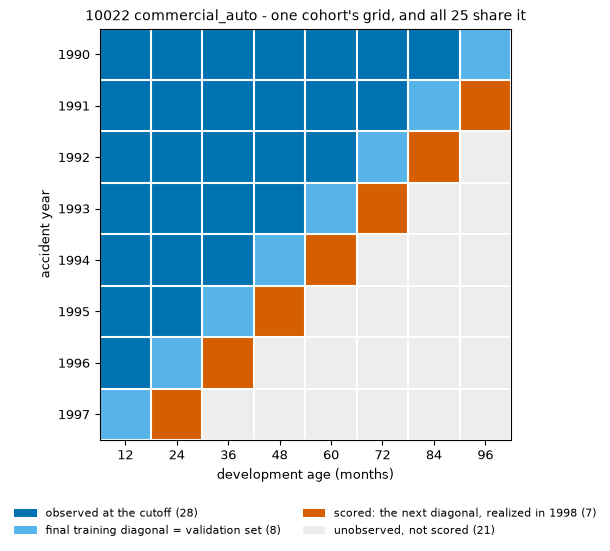

8 accident years x 8 development ages = 64 cells: 36 observed at 1997-12-31 (8 of them the final training diagonal), 7 scored, 21 unobserved.
1 further next-diagonal cell(s) fall beyond this grid, excluded as dev_beyond_trained: accident year 1990 at 108 months


In [8]:
# The picture, derived from the objects the board is built from: the training slice for
# the observed cells, the held-out census for the scored ones.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def _locations(frame):
    """(origin_period, dev_lag) pairs of a frame, as a hashable set."""
    return frozenset(
        zip(
            pd.to_datetime(frame["origin_period"]).dt.date,
            frame["dev_lag"].astype(int),
            strict=True,
        )
    )


_train = tri.as_of(AS_OF).expr.execute()
_train = _train[_train["field"] == FIELD]
_observed = {k: _locations(g) for k, g in _train.groupby(["company_code", "line_of_business"])}
_scored = {k: _locations(v.frame[v.frame["field"] == FIELD]) for k, v in cells.items()}
_beyond = {k: _locations(v.excluded[v.excluded["field"] == FIELD]) for k, v in cells.items()}
_why = {
    k: tuple(sorted(set(v.excluded.loc[v.excluded["field"] == FIELD, "reason"])))
    for k, v in cells.items()
}

# One grid speaks for the panel only if every cohort has that grid: same accident
# years, same development ages, same scored locations, same exclusions, on all
# twenty-five cohorts. The assert is what lets one figure stand for all of them.
assert len({(_observed[k], _scored[k], _beyond[k], _why[k]) for k in COHORTS}) == 1

_key = COHORTS[0]
_origins = sorted({o for o, _ in _observed[_key]})
_devs = sorted({d for _, d in _observed[_key] | _scored[_key]})
_oi = {o: i for i, o in enumerate(_origins)}
_di = {d: j for j, d in enumerate(_devs)}
# calendar index: cells sharing origin index + dev index share an evaluation date, so the
# largest one among the observed cells IS the final training diagonal
_cal = {(o, d): _oi[o] + _di[d] for o in _origins for d in _devs}
_last_train = max(_cal[c] for c in _observed[_key])

_TRAIN, _VALID, _SCORED, _FUTURE = 0, 1, 2, 3
_grid = np.full((len(_origins), len(_devs)), _FUTURE)
for _o, _d in _observed[_key]:
    _grid[_oi[_o], _di[_d]] = _VALID if _cal[(_o, _d)] == _last_train else _TRAIN
for _o, _d in _scored[_key]:
    _grid[_oi[_o], _di[_d]] = _SCORED

_colors = ["#0072B2", "#56B4E9", "#D55E00", "#EDEDED"]
_labels = [
    f"observed at the cutoff ({int((_grid == _TRAIN).sum())})",
    f"final training diagonal = validation set ({int((_grid == _VALID).sum())})",
    f"scored: the next diagonal, realized in 1998 ({int((_grid == _SCORED).sum())})",
    f"unobserved, not scored ({int((_grid == _FUTURE).sum())})",
]

fig, ax = plt.subplots(figsize=(7.0, 5.4), layout="constrained")
ax.imshow(_grid, cmap=ListedColormap(_colors), vmin=0, vmax=3)
ax.set_xticks(range(len(_devs)), [str(d) for d in _devs], fontsize=9)
ax.set_yticks(range(len(_origins)), [str(o.year) for o in _origins], fontsize=9)
ax.set_xticks(np.arange(-0.5, len(_devs)), minor=True)
ax.set_yticks(np.arange(-0.5, len(_origins)), minor=True)
ax.grid(which="minor", color="white", lw=1.5)
ax.tick_params(which="minor", length=0)
ax.set_xlabel("development age (months)", fontsize=9)
ax.set_ylabel("accident year", fontsize=9)
ax.set_title(f"{_key[0]} {_key[1]} - one cohort's grid, and all 25 share it", fontsize=10)
ax.legend(
    handles=[Patch(facecolor=c, label=t) for c, t in zip(_colors, _labels, strict=True)],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    fontsize=8,
    frameon=False,
)
plt.show()

print(
    f"{len(_origins)} accident years x {len(_devs)} development ages = {_grid.size} cells: "
    f"{int((_grid < _SCORED).sum())} observed at {AS_OF} "
    f"({int((_grid == _VALID).sum())} of them the final training diagonal), "
    f"{int((_grid == _SCORED).sum())} scored, {int((_grid == _FUTURE).sum())} unobserved."
)
_excluded = sorted((o.year, d) for o, d in _beyond[_key])
print(
    f"{len(_excluded)} further next-diagonal cell(s) fall beyond this grid, excluded as "
    f"{', '.join(_why[_key])}: "
    + ", ".join(f"accident year {y} at {d} months" for y, d in _excluded)
)

## Entry capabilities

A forecast carries two independent capabilities, and the separation is what lets one board
hold entries of very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive density;
* `PredictsHeldout` -> `predict_at()` -> predictive draws, and hence CRPS.

The continuous ranked probability score (CRPS) generalizes absolute error to a
distributional forecast: it is the average absolute difference between a draw from the
forecast and the realized value, less half the average absolute difference between two
independent draws - the second term charging the forecast for its own spread, so neither a
wide hedge nor a false certainty scores well. For a point forecast it reduces to absolute
error; lower is better.

An entry may have either, both, or neither, and the two are not redundant. `mack` draws from
a bootstrap and states no observation model, so it has draws and no density. `sur` subclasses
neither mixin, so it cannot appear in a held-out score column at all, and is compared at the
ultimate level in the appendix instead. That is a limitation of the entry, not of the panel.

The roster below is built from the live registry. `config_class` is the same idea one level
down: it is how an entry names the dataclass its `fit(config=...)` takes.

In [9]:
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
                "config_class": getattr(cls.config_class, "__name__", "-"),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{(~roster['density'] & ~roster['draws (CRPS)']).sum()} neither"
)
# The entries this notebook uses, in the order they appear: the five on the held-out
# board, then `sur` and `nn_paid_case`, which the ultimates section adds.
ON_THIS_BOARD = ["mack", "nn_transformer", "mdn", "resnet", "deeptriangle"]
display(
    roster[roster["entry"].isin([*ON_THIS_BOARD, "sur", "nn_paid_case"])].reset_index(drop=True)
)

16 registered entries; 9 density, 13 draws, 3 neither


,entry,family,density,draws (CRPS),config_class
0,mack,deterministic,False,True,-
1,deeptriangle,nn,True,True,DeepTriangleConfig
2,mdn,nn,True,True,MDNConfig
3,nn_paid_case,nn,True,True,NNPaidCaseConfig
4,nn_transformer,nn,True,True,TransformerConfig
5,resnet,nn,True,True,ResNetConfig
6,sur,statistical,False,False,-


## Models and fitting

Every entry is fitted with exactly the arguments in the next cell. Nothing is tuned per
cohort.

`mack` is fitted separately on each cohort's
triangle: twenty-five independent fits. Each neural entry is fitted once, on all twenty-five
cohorts together, and that one fit supplies every cohort's forecast. Pooling is how these
models are designed to be used - a single Schedule P triangle carries 36 usable cells in
this window, too few to train a network - but it means a neural forecast draws on the loss
history of all twenty-five cohorts while the `mack` forecast beside it draws on one. The
limitations section states what this asymmetry costs the comparison. It also affects the
timing table below: `mack`'s time is the sum of twenty-five fits, and each neural time is a
single fit, so the raw seconds do not compare the same unit of work.

In [10]:
# The methods section, in one dict.
PER_COHORT_CONFIG = {
    "mack": dict(sigma_rule="mack", heldout_n_draws=10_000),
}
# mack's fit() takes NO seed - it is a deterministic estimator, and the randomness
# is in predict() / predict_at(), which the heldout_* knobs above configure.
#
# The NN entries fit ONCE, pooled over the whole panel, then predict per cohort.
# 120 epochs / 5 ensemble members is the demonstrative cut of the published study's
# 400 epochs - see the limitations section. n_draws is the ROLLOUT budget, spent once
# per future calendar diagonal by predict(); the held-out draws behind the board come
# from each config's own heldout_n_draws, left at its 0.5.5 default of 10,000.
NN_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)
NN_ENTRIES = ["nn_transformer", "mdn", "resnet", "deeptriangle"]

pd.DataFrame(
    [{"entry": k, "how": "per cohort", "config": str(v)} for k, v in PER_COHORT_CONFIG.items()]
    + [{"entry": n, "how": "pooled fit", "config": str(NN_CONFIG)} for n in NN_ENTRIES]
)

,entry,how,config
0,mack,per cohort,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,nn_transformer,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
2,mdn,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
3,resnet,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
4,deeptriangle,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."


### The scoring helper

The helper below is the API surface this notebook exists to show, so it is written out in
full. `Absence` is why a missing array is never a bare `None`: the board has to distinguish
an entry that has no density at all from a run that refused one cohort. The vocabulary is
closed - `fit_failed`, `no_cell_sampler`, `no_predictive_density`, `not_offered`,
`scorer_not_implemented`, `scoring_refused`.

`point_row` also retains the draws behind each cohort's total ultimate. The multi-line
appendix needs them: comparing a single-line entry against `sur` at the company level means
summing a company's lines within a draw, and that sum is exactly the independence assumption
`sur` exists to relax.

In [11]:
refusals: list[dict] = []
point_rows: list[dict] = []
ultimate_draws: dict[tuple[str, tuple[str, str]], np.ndarray] = {}


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one cohort's held-out cells -> one CohortForecast."""
    kw = {}

    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: it states no observation model.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def fit_or_absent(name, key, **kwargs):
    """gallery.fit, or a forecast that records why there is none.

    A fit that raises must not silently vanish: an absent model row reads as
    "not run", while `fit_failed` on both axes says what happened and drops the
    cohort from that score's panel for the models that share it.
    """
    try:
        return gallery.fit(name, sub[key], loss_field=FIELD, as_of=AS_OF, **kwargs), None
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="fit", error=repr(exc)[:200]))
        return None, CohortForecast.unavailable(
            model=name,
            task=TASK,
            cells=cells[key],
            field=FIELD,
            density_reason="fit_failed",
            draws_reason="fit_failed",
            detail=f"{type(exc).__name__}: {exc}"[:150],
        )


def point_row(name, entry, key):
    """Ultimate-level point estimate vs the realized outcome, for the same fit.

    predict() targets are per origin plus a 'total' row; realized_ultimates()
    aligns to them from the FULL triangle and restricts to the origins the
    training slice actually had - the mart runs to 2007, and an unrestricted
    aggregate is inflated by roughly 2.4x.
    """
    # ONE call shape for every entry. `segment` is a filter on the fit's own cohorts,
    # so a two-column key identifies the one cohort of a single-cohort fit keyed on
    # three, and names the cohort of a pooled fit keyed on two.
    seg = {"company_code": key[0], "line_of_business": key[1]}
    pred = entry.predict(segment=seg, seed=SEED_DRAW)
    outcome = entry.realized_ultimates(sub[key], segment=seg)
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    mean = float(pred.mean()[i])
    actual = float(np.asarray(outcome, dtype=float)[i])
    row = dict(
        model=name,
        company_code=key[0],
        line_of_business=key[1],
        predicted_ultimate=mean,
        realized_ultimate=actual,
        pct_error=100.0 * (mean - actual) / actual,
        outcome_pct=100.0 * float(pred.cdf(np.asarray(outcome, dtype=float))[i]),
    )
    # Kept for the multiline appendix: the draw axis behind this cohort's total.
    ultimate_draws[(name, key)] = np.asarray(pred.samples[:, i], dtype=float)
    return row


def record_point(name, entry, key):
    """point_row, but a refusal is recorded rather than ending the run."""
    try:
        point_rows.append(point_row(name, entry, key))
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="ultimate", error=repr(exc)[:200]))

In [12]:
forecasts: list[CohortForecast] = []
fit_seconds: dict[str, float] = {}

for name, kwargs in PER_COHORT_CONFIG.items():
    t0 = time.perf_counter()
    for key in COHORTS:
        # Build the forecast and the point row INSIDE the loop, then drop the entry:
        # a fitted entry carries its draws, and 25 of them at a time is needless memory.
        entry, absent = fit_or_absent(name, key, **kwargs)
        if entry is None:
            forecasts.append(absent)
            continue
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
        del entry
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  "
        f"({fit_seconds[name] / len(COHORTS):.1f}s per cohort)",
        flush=True,
    )
print(f"\nrefusals so far: {len(refusals)}")
for r in refusals:
    print("  ", r)

mack                       5.3s  (0.2s per cohort)



refusals so far: 0


In [13]:
# One pooled fit per entry over the WHOLE panel triangle, then 25 cohort forecasts
# off it. One fit therefore serves 25 cohorts, and the clustering unit for any paired
# test on these rows is the FIT (the whole panel), not the cohort.
#
# Each entry names its own config dataclass: gallery.get(name).config_class is the
# ClassVar the registry checks at registration.
nn_fits = {}
for name in NN_ENTRIES:
    ConfigCls = gallery.get(name).config_class
    t0 = time.perf_counter()
    entry = gallery.fit(
        name, tri, loss_field=FIELD, as_of=AS_OF, seed=SEED_FIT, config=ConfigCls(**NN_CONFIG)
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    nn_fits[name] = entry
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  (pooled fit {t_fit:.1f}s + "
        f"{fit_seconds[name] - t_fit:.1f}s scoring 25 cohorts)",
        flush=True,
    )

nn_transformer            68.1s  (pooled fit 53.6s + 14.5s scoring 25 cohorts)


mdn                       13.7s  (pooled fit 8.8s + 4.9s scoring 25 cohorts)


resnet                    28.6s  (pooled fit 21.9s + 6.7s scoring 25 cohorts)


deeptriangle              29.1s  (pooled fit 21.3s + 7.8s scoring 25 cohorts)


## Results

`align_panel` builds the panel of the opening section as an object: the intersection of the
cells every member can answer on, with whatever is dropped itemized. `leaderboard` scores
them. Because a forecast carries two independent capabilities, each score gets its own
panel: its own membership, its own intersection of cells, and its own fingerprint, stamped
on every board row, so that a number always carries the set of models that produced it.

No held-out density is reported on this roster. `mack` has none to give, and the four neural
entries decline one on every cohort of this panel, for the reason set out in the inference
section below. The board is therefore CRPS; point error and calibration follow in the two
sections after it.

Three points on reading the table.

* A missing score is `pd.NA` and never `0.0`, which on this board would be the best value
  there is. Totals are reduced in Python from each model's own array, because a grouped sum
  over an all-missing group returns 0.0 in pandas.
* `leaderboard()` has no default sort and no `sort_by=` argument. `SCORE_DIRECTION` records
  each column's direction machine-readably; the sort below is this notebook's choice, not the
  library's.
* `n_draws_sample_min` is the raw draw count behind the worst cell's CRPS, and every row
  here rests on 10,000. `mack` takes that count from the `heldout_n_draws` fit argument in
  the configuration cell above, and each neural entry from the identically named field on
  its own config, which ibnr 0.5.5 sets to 10,000. Through 0.5.3 the neural held-out draws
  came from the rollout's `n_draws` instead, so this notebook's 500 would have put the
  neural rows on a twentieth of `mack`'s sample; sample CRPS carries an upward bias of order
  1/n_draws, and the smaller sample pays it.

In [14]:
panel = align_panel(forecasts, units=tri.meta.units)
print(f"task {panel.task} @ {panel.as_of}")
print(f"CRPS panel: {panel.n_cells_for('crps')} cells over {panel.n_cohorts_for('crps')} cohorts")
print("            members    ", list(panel.crps_members))
print("            fingerprint", panel.crps_fingerprint)
print("            dropped    ", len(panel.dropped), "cells")

task paid_loss@1997 @ 1997-12-31
CRPS panel: 175 cells over 25 cohorts
            members     ['deeptriangle', 'mack', 'mdn', 'nn_transformer', 'resnet']
            fingerprint bca75d8a6a13005c
            dropped     0 cells


In [15]:
board = gallery.leaderboard(panel)
view = board[
    [
        "model",
        "n_cohorts",
        "n_cells_crps",
        "crps",
        "crps_per_cell",
        "n_draws_sample_min",
    ]
].copy()
print("score direction:", {k: v for k, v in SCORE_DIRECTION.items() if k.startswith("crps")})
view.sort_values("crps_per_cell").round(3)

score direction: {'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
1,mack,25,175,560679.411,3203.882,10000
0,deeptriangle,25,175,696303.445,3978.877,10000
4,resnet,25,175,754157.625,4309.472,10000
2,mdn,25,175,890439.982,5088.228,10000
3,nn_transformer,25,175,1825607.32,10432.042,10000


### What the panel cost

`panel.dropped` names every cell a member offered that the panel could not use, and which
member lacked it. `panel.coverage` reports what each model offered and what survived. The refusals table below is this run's own
record of the four neural entries declining a density on twenty-five cohorts each, with the
error text naming the pinned development step.

In [16]:
print("dropped cells:", len(panel.dropped))
if len(panel.dropped):
    display(panel.dropped.head(12))
    print("\ndropped by score:", panel.dropped["score"].value_counts().to_dict())

# Summarised, not listed: the NN density refusals alone are one per (entry, cohort),
# and a hundred near-identical lines would bury anything that is not one of them.
print("\nrun-level refusals recorded by the helper:", len(refusals))
_ref = pd.DataFrame(refusals)
if len(_ref):
    _ref["error (truncated)"] = _ref["error"].str.slice(0, 70)
    display(
        _ref.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )
display(
    panel.coverage[
        [c for c in panel.coverage.columns if "crps" in c or c in ("model", "n_cohorts_offered")]
    ]
)
print("upstream exclusions (same for every model, by construction):")
display(panel.excluded.head(10))

dropped cells: 0

run-level refusals recorded by the helper: 100


,model,axis,error (truncated),cohorts
0,deeptriangle,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
1,mdn,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
2,nn_transformer,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
3,resnet,density,ValueError('1 cell(s) sit at pinned dev step(s...,25


,model,n_cohorts_offered,is_crps_member,crps_status,n_cohorts_crps,n_cells_crps_own,n_cells_crps_on_panel,n_cells_crps_dropped
0,deeptriangle,25,True,scored,25,175,175,0
1,mack,25,True,scored,25,175,175,0
2,mdn,25,True,scored,25,175,175,0
3,nn_transformer,25,True,scored,25,175,175,0
4,resnet,25,True,scored,25,175,175,0


upstream exclusions (same for every model, by construction):


,cohort,new_origin,dev_beyond_trained,no_predecessor,n_scorable
0,"(10022, commercial_auto)",0,2,0,7
1,"(10022, private_passenger_auto)",0,2,0,7
2,"(14044, commercial_auto)",0,2,0,7
3,"(14044, other_liability)",0,2,0,7
4,"(14044, private_passenger_auto)",0,2,0,7
5,"(1767, commercial_auto)",0,2,0,7
6,"(1767, other_liability)",0,2,0,7
7,"(1767, private_passenger_auto)",0,2,0,7
8,"(1767, workers_compensation)",0,2,0,7
9,"(18767, commercial_auto)",0,2,0,7


## Ultimate-level point estimates

The held-out board scores one diagonal. A reserving audience also wants the number the model
delivers: the predicted ultimate against what the later statements revealed. Every row below
comes from `entry.predict()` and `entry.realized_ultimates()` on the fits used above.
`realized_ultimates` restricts to the origins the training slice had, 1990 through 1997 on
this window, which keeps the mart's later accident years out of the aggregate.

This is the table where the difference in information bites hardest: each neural row is a
single fit pooled over all twenty-five cohorts, and `mack` is twenty-five separate fits.

In [17]:
points = pd.DataFrame(point_rows)
totals = points.groupby("model")[["predicted_ultimate", "realized_ultimate"]].sum()
per_model = points.groupby("model").agg(
    cohorts=("pct_error", "size"),
    median_pct_error=("pct_error", "median"),
    mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
    median_outcome_pct=("outcome_pct", "median"),
)
# Aggregate error over the panel as a whole - dollar-weighted, so it is the number a
# reserving audience reads, and it is NOT the mean of the per-cohort percentage errors.
per_model["aggregate_pct_error"] = 100.0 * (
    totals["predicted_ultimate"] / totals["realized_ultimate"] - 1.0
)
display(per_model.sort_values("mean_abs_pct_error").round(2))
print(
    "aggregate_pct_error is per model, over the cohorts that model produced an ultimate "
    "for, so the rows are not all over the same dollars."
)
for _m, _n in per_model.loc[per_model["cohorts"] < len(COHORTS), "cohorts"].items():
    _missed = sorted(r["cohort"] for r in refusals if r["model"] == _m and r["axis"] == "ultimate")
    print(
        f"  {_m}: {int(_n)} of {len(COHORTS)} cohorts - predict() refused {_missed}, so those "
        "dollars are out of both its numerator and its denominator."
    )
display(
    points.pivot_table(
        index="line_of_business", columns="model", values="pct_error", aggfunc="median"
    ).round(1)
)

,cohorts,median_pct_error,mean_abs_pct_error,median_outcome_pct,aggregate_pct_error
model,,,,,
deeptriangle,25,2.11,4.31,24.80,2.88
resnet,25,2.84,5.21,29.60,5.12
mack,25,1.72,5.24,24.31,1.13
mdn,25,3.07,5.73,15.00,4.87
nn_transformer,25,4.12,7.35,20.00,8.81


aggregate_pct_error is per model, over the cohorts that model produced an ultimate for, so the rows are not all over the same dollars.


model,deeptriangle,mack,mdn,nn_transformer,resnet
line_of_business,,,,,
commercial_auto,1.6,8.9,2.9,5.8,4.0
other_liability,-8.2,-1.8,-6.2,-8.8,-5.0
private_passenger_auto,2.7,0.7,5.7,5.4,4.4
workers_compensation,3.3,2.0,3.6,1.2,2.2


## Calibration on the held-out cells

The probability integral transform of a held-out cell is the fraction of predictive draws at
or below the realized outcome. If the predictive distribution is correct the PITs are
Uniform(0, 1), and `ks_uniformity` is the two-sided Kolmogorov-Smirnov test of that
hypothesis, reported here as D x 100 in the convention of the Meyers monograph, with an
asterisk where it rejects at 5%.

The 5% band assumes independent observations, and these cells are not independent. Three
dependences are present on this panel:

1. the 7 cells of a cohort come from one fit on one triangle, and they are consecutive
   development lags of neighbouring accident years;
2. the twenty-five cohorts belong to ten companies, so cohorts sharing a company share its
   case-reserving practice and its calendar-year effects;
3. the four neural rows are one pooled fit each, so all of their cells come from a single
   estimation.

Under positive dependence the effective number of observations is smaller than `n`, the null
distribution of `D` is wider than `1.36/sqrt(n)`, and a test at that band over-rejects. The
cell-level table below is therefore descriptive: the statistic and the p-p curve, with no
critical value and no pass/fail column.

The calibrated test runs one level up. `predict_at` returns joint draws - each row is one
draw across all of a cohort's cells at once - so summing within a draw gives the predictive
distribution of that cohort's whole next diagonal, and the PIT of the realized total is one
observation per cohort. Dependence 1 is integrated out exactly rather than adjusted for, and
dependence 3 no longer affects the null, because every model is then tested on one
observation per cohort. Dependence 2 survives, and is disclosed rather than corrected: ten
companies are far too few blocks to bootstrap. At this sample size the test has little power
against anything short of gross miscalibration.

In [18]:
crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])
collected: dict[str, list[np.ndarray]] = {}
cohort_pit_rows: list[dict] = []
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    p = (f.draws <= values[None, :]).mean(axis=0)  # empirical predictive CDF at the outcome
    on = np.array([k in crps_keys for k in f.keys])
    if not on.any():  # the whole cohort fell off the CRPS panel
        continue
    collected.setdefault(f.model, []).append(p[on])
    # ONE PIT per cohort, off the SAME draws: sum the panel's cells within each draw
    # first, so the cohort's joint predictive of its next-diagonal total is what gets
    # tested and the within-cohort dependence is integrated out.
    totals = f.draws[:, on].sum(axis=1)
    cohort_pit_rows.append(
        dict(model=f.model, cohort=f.cohort, pit=float((totals <= values[on].sum()).mean()))
    )
pits = {m: np.concatenate(v) for m, v in collected.items()}

ks = (
    pd.DataFrame(
        [
            {"model": m, "n_cells": r.n, "D x 100": 100 * r.statistic, "mean_pit": float(p.mean())}
            for m, p in pits.items()
            for r in [ks_uniformity(p)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
print(
    "DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent\n"
    "(7 per cohort from one fit, 25 cohorts over 10 companies, the four NN rows one\n"
    "pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below."
)
ks.round(3)

DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent
(7 per cohort from one fit, 25 cohorts over 10 companies, the four NN rows one
pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below.


,model,n_cells,D x 100,mean_pit
0,deeptriangle,175,13.966,0.434
1,mack,175,14.810,0.444
2,nn_transformer,175,14.926,0.424
3,resnet,175,16.861,0.410
4,mdn,175,17.317,0.406


In [19]:
cohort_pits = pd.DataFrame(cohort_pit_rows)
ks_cohort = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_cohorts": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["pit"].mean()),
            }
            for m, g in cohort_pits.groupby("model")
            for r in [ks_uniformity(g["pit"].to_numpy())]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
# Every model tested on the SAME cohorts, or the D values are not comparable and the
# shared critical value is not shared. The CRPS panel is what guarantees it.
_n = sorted(set(ks_cohort["n_cohorts"]))
assert len(_n) == 1, ks_cohort
_companies = cohort_pits["cohort"].map(lambda c: c[0]).nunique()
print(
    f"one PIT per cohort, from that cohort's joint next-diagonal total: n = {_n[0]} "
    f"cohorts over {_companies} companies,\ncritical value "
    f"{ks_cohort['critical 5% x 100'].iloc[0]:.1f}. Cohorts of one company "
    "still share its reserving practice, so these are\nnear-independent rather than "
    f"independent; and at n = {_n[0]} the test only sees gross miscalibration."
)
ks_cohort.round(3)

one PIT per cohort, from that cohort's joint next-diagonal total: n = 25 cohorts over 10 companies,
critical value 27.2. Cohorts of one company still share its reserving practice, so these are
near-independent rather than independent; and at n = 25 the test only sees gross miscalibration.


,model,n_cohorts,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,nn_transformer,25,26.06,27.2,0.067,True,0.357
1,deeptriangle,25,30.47,27.2,0.019,False,0.344
2,resnet,25,31.49,27.2,0.014,False,0.320
3,mdn,25,37.00,27.2,0.002,False,0.285
4,mack,25,48.78,27.2,0.000,False,0.221


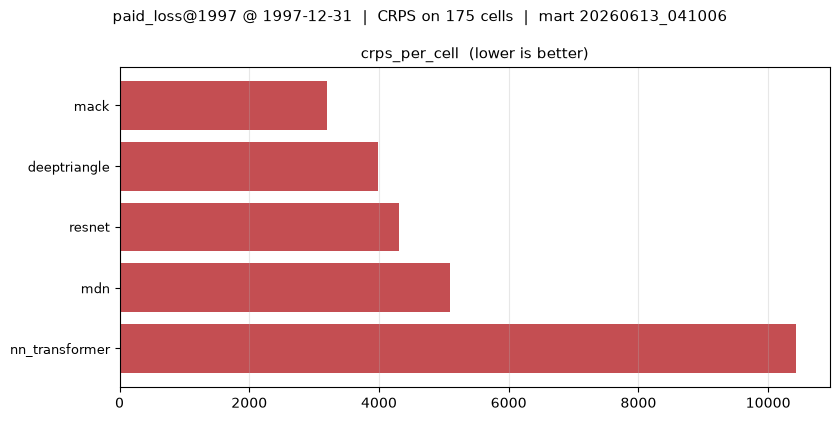

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(board) + 2.0))
order = board.sort_values("crps_per_cell")["model"].tolist()
y = np.arange(len(order))
vals = pd.to_numeric(board.set_index("model").loc[order, "crps_per_cell"], errors="coerce")

ax.barh(y, vals.to_numpy(dtype=float), color="#c44e52")
ax.set_yticks(y, order, fontsize=9)
ax.invert_yaxis()
ax.set_title("crps_per_cell  (lower is better)", fontsize=11)
ax.axvline(0, color="black", lw=0.6)
ax.grid(axis="x", alpha=0.3)
fig.suptitle(
    f"{TASK} @ {panel.as_of}  |  CRPS on {panel.n_cells_for('crps')} cells  |  mart {PUBLISH_ID}",
    fontsize=11,
)
fig.tight_layout()
plt.show()

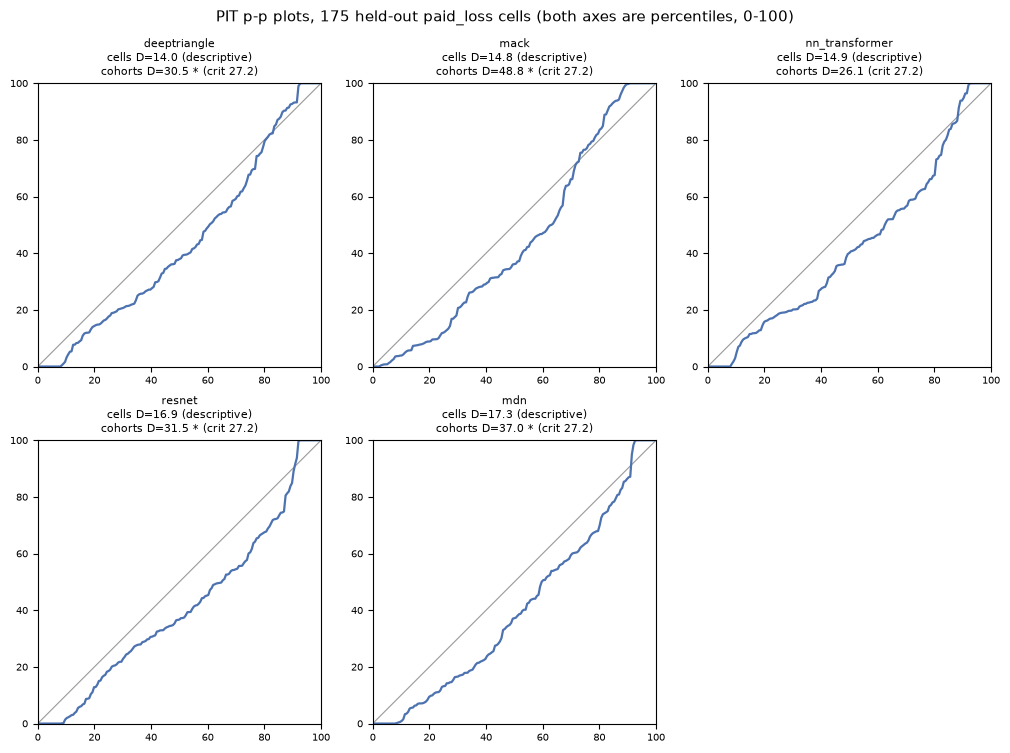

5 panels, [175] points each, on 0-100 axes


In [21]:
# pp_points returns PERCENTILES - (expected * 100, sorted PIT * 100), the
# convention of the Meyers monograph. So the axes and the reference
# diagonal run 0-100 as well. Drawn against a [0, 1] diagonal with xlim/ylim (0, 1),
# every one of these points falls outside the window and the visible line is a
# clipping artifact, not the curve.
#
# The curves are the CELL-level PITs and are descriptive; the asterisk in each
# title is the COHORT-level test, which is the one with a valid null.
models = ks.sort_values("D x 100")["model"].tolist()
ncol = min(3, len(models))
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.8 * nrow), squeeze=False)
n_points = {}
_kc = ks_cohort.set_index("model")
for ax, m in zip(axes.ravel(), models):
    x, y = pp_points(pits[m])
    n_points[m] = len(x)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, color="#4c72b0")
    r = ks.set_index("model").loc[m]
    rc = _kc.loc[m]
    flag = "" if rc["passes"] else " *"
    ax.set_title(
        f"{m}\ncells D={r['D x 100']:.1f} (descriptive)\n"
        f"cohorts D={rc['D x 100']:.1f}{flag} (crit {rc['critical 5% x 100']:.1f})",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(models) :]:
    ax.axis("off")
fig.suptitle(
    f"PIT p-p plots, {panel.n_cells_for('crps')} held-out {FIELD} cells "
    "(both axes are percentiles, 0-100)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

# This assert checks that every point lies inside the axes, instead of trusting
# visual inspection.
assert set(n_points.values()) == {panel.n_cells_for("crps")}, n_points
print(f"{len(n_points)} panels, {sorted(set(n_points.values()))} points each, on 0-100 axes")

## Ultimates across methods and fields

The comparison so far scores one field. This section fits the same methods on the incurred
field and puts the ultimate-level results for both fields side by side. The paid side also
gains three rows, from the case-reserve work in ibnr 0.5.5: one new neural entry, and a new
head on an entry already here. A case reserve is the claims department's own estimate of what
is still owed on the claims it has been told about. It is a snapshot at each evaluation date
rather than an amount that accumulates, which is what makes it awkward to feed a model built
for cumulative losses and interesting to model directly.

Two of those rows come from `nn_paid_case`, the sixth neural entry. It models a cohort's paid
increment and its case-reserve movement jointly, with one bivariate mixture distribution per
cell, so the relationship between a payment and the reserve it draws down is something the
network learns cell by cell rather than something assumed. The case reserve is treated as a
state and not a fixed input: the rollout adds each sampled movement to the running case level
and conditions the next diagonal on the result, which is what lets a projection several years
long still carry a case position. The entry ships two encoder bodies, a transformer and a GRU,
behind the same head, the same loss and the same rollout, so `nn_paid_case` and
`nn_paid_case_gru` differ in the encoder alone.

The third new row, `deeptriangle_case`, is the entry already on the board fitted with its
case-reserve head. `deeptriangle` trains a second head beside the paid one as a regularizer,
and by default that head learns claims outstanding, derived from its reported-loss channel.
Here the second channel is the case reserve carried undifferenced - an eval-date snapshot
rather than an amount that accumulates - and the auxiliary head learns that level itself. The
plain `deeptriangle` row stays beside it, so the two differ in what the second channel holds
and in what the auxiliary head is trained on.

Incurred here is `reported_loss`: incurred loss net of bulk reserves, Schedule P's
`IncurLoss` less `BulkLoss`. The bulk provision is a company-level judgement booked on top
of the case estimates, and it moves with reserving policy rather than with claims. The
definition changes the verdict. Meyers' own validation, reproduced in this package, passes
its calibration test on all four lines net of bulk and fails workers compensation gross of
it.

Paid and incurred are different outcomes. Each is scored against its own field's realized
value at the deepest development age the study window holds. The incurred value there still
contains case reserves, so an incurred ultimate at 96 months is an estimate of what the
accident year will cost; the paid figure beside it is the cash paid so far. A method can be
accurate on one field and inaccurate on the other, and the table below reports both.

The panel is the one every section above uses, and the screen that built it is defined on
paid positivity. Incremental incurred losses go negative at late development ages, where
case reserves are released faster than payments replace them. The methods differ in how
they handle those negative increments, which the table also reports.

All three new rows sit on the paid side. `nn_paid_case` is a paid-arm model by construction:
reported losses already contain the case reserve, so a joint model of the reported increment
and the case movement would count every case movement inside both of its own targets. The
case channel is a paid-side question for `deeptriangle_case` too, since against an incurred
target the case reserve is part of the quantity being predicted rather than a separate signal
about it.

The gallery's remaining cross-line entry, `copula_glm`, cannot take this field: its
lognormal marginals need positive increments. `sur` takes both fields, because its only
positivity guard is on cumulatives, the quantity its whitening step divides by.


In [22]:
# The second field, and the rows the paid side already has.
FIELD2 = "reported_loss"
ULT_FIELDS = [FIELD, FIELD2]

ult_rows: list[dict] = []
ult_draw: dict[tuple[str, str, tuple[str, str]], np.ndarray] = {}
ult_refusals: list[dict] = []
ult_seconds: dict[tuple[str, str], float] = {}


def add_ultimate(model, field, key, pred, outcome, label):
    """One cohort's ultimate row for one field, plus the draws behind it.

    `label` names the target row carrying that cohort's ultimate: "total" on a
    per-cohort or pooled fit, and "<line>/total" on a company-wide `sur` fit,
    whose targets span every line the company writes. The predicted value is the
    mean of that row's draws, exactly as `record_point` takes it above.
    """
    outcome = np.asarray(outcome, dtype=float)
    i = pred.targets["label"].astype(str).tolist().index(label)
    ult_draw[(model, field, key)] = np.asarray(pred.samples[:, i], dtype=float)
    ult_rows.append(
        dict(
            model=model,
            field=field,
            company_code=key[0],
            line_of_business=key[1],
            predicted_ultimate=float(pred.mean()[i]),
            realized_ultimate=float(outcome[i]),
            premium=float(PREMIUM_TOTAL[key]),
            outcome_pct=100.0 * float(pred.cdf(outcome)[i]),
        )
    )


# The paid ultimates are the ones the sections above already produced, off the fits the
# board was scored on. Refitting would be a second run of an identical call.
for _r in point_rows:
    _key = (_r["company_code"], _r["line_of_business"])
    ult_rows.append(
        dict(
            model=_r["model"],
            field=FIELD,
            company_code=_key[0],
            line_of_business=_key[1],
            predicted_ultimate=_r["predicted_ultimate"],
            realized_ultimate=_r["realized_ultimate"],
            premium=float(PREMIUM_TOTAL[_key]),
            outcome_pct=_r["outcome_pct"],
        )
    )
    ult_draw[(_r["model"], FIELD, _key)] = ultimate_draws[(_r["model"], _key)]
print(f"{len(ult_rows)} paid rows carried over from the fits above")

125 paid rows carried over from the fits above


In [23]:
# The three new paid rows: one pooled fit each over the whole panel, then one predict per
# cohort, the same shape as the paid fits the sections above ran. Same config, same seeds.
#
# `nn_paid_case` takes `paid_field` / `case_field` and deliberately no `loss_field`,
# `feature_fields` or `level_fields`: its two channels ARE the entry, so there is nothing
# for a caller to choose. `deeptriangle` takes the case reserve as a feature carried
# undifferenced, which is what switches its auxiliary head onto the case level.
PaidCaseConfig = gallery.get("nn_paid_case").config_class
DeepTriangleConfig = gallery.get("deeptriangle").config_class

NEW_PAID_FITS = [
    (
        "nn_paid_case",
        "nn_paid_case",
        dict(
            paid_field=FIELD,
            case_field="case_reserve",
            config=PaidCaseConfig(**NN_CONFIG),
        ),
    ),
    (
        "nn_paid_case_gru",
        "nn_paid_case",
        dict(
            paid_field=FIELD,
            case_field="case_reserve",
            config=PaidCaseConfig(backbone="gru", hidden_dim=64, **NN_CONFIG),
        ),
    ),
    (
        "deeptriangle_case",
        "deeptriangle",
        dict(
            loss_field=FIELD,
            feature_fields=("case_reserve",),
            level_fields=("case_reserve",),
            config=DeepTriangleConfig(**NN_CONFIG),
        ),
    ),
]

# The two nn_paid_case fits are kept alive for the drain diagnostic at the end of this
# section; it reads the same cached rollout these ultimates come from.
paid_case_fits: dict[str, object] = {}

for row_name, entry_name, fit_kwargs in NEW_PAID_FITS:
    t0 = time.perf_counter()
    entry = gallery.fit(entry_name, tri, as_of=AS_OF, seed=SEED_FIT, **fit_kwargs)
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        seg = {"company_code": key[0], "line_of_business": key[1]}
        try:
            add_ultimate(
                row_name,
                FIELD,
                key,
                entry.predict(segment=seg, seed=SEED_DRAW),
                entry.realized_ultimates(sub[key], segment=seg),
                "total",
            )
        except Exception as exc:
            ult_refusals.append(
                dict(model=row_name, field=FIELD, cohort=key, error=repr(exc)[:180])
            )
    ult_seconds[(row_name, FIELD)] = round(time.perf_counter() - t0, 1)
    if entry_name == "nn_paid_case":
        paid_case_fits[row_name] = entry
    else:
        del entry
    print(
        f"{row_name:18s} {FIELD:14s} {ult_seconds[(row_name, FIELD)]:7.1f}s  "
        f"(pooled fit {t_fit:.1f}s + "
        f"{ult_seconds[(row_name, FIELD)] - t_fit:.1f}s over 25 cohorts)",
        flush=True,
    )

nn_paid_case       paid_loss         51.8s  (pooled fit 38.1s + 13.7s over 25 cohorts)


nn_paid_case_gru   paid_loss         35.4s  (pooled fit 27.2s + 8.2s over 25 cohorts)


deeptriangle_case  paid_loss         30.6s  (pooled fit 23.3s + 7.3s over 25 cohorts)


In [24]:
# mack on incurred: twenty-five independent per-cohort fits, the same kwargs as the board.
t0 = time.perf_counter()
for key in COHORTS:
    seg = {"company_code": key[0], "line_of_business": key[1]}
    try:
        entry = gallery.fit(
            "mack", sub[key], loss_field=FIELD2, as_of=AS_OF, **PER_COHORT_CONFIG["mack"]
        )
        add_ultimate(
            "mack",
            FIELD2,
            key,
            entry.predict(segment=seg, seed=SEED_DRAW),
            entry.realized_ultimates(sub[key], segment=seg),
            "total",
        )
        del entry
    except Exception as exc:
        ult_refusals.append(dict(model="mack", field=FIELD2, cohort=key, error=repr(exc)[:180]))
ult_seconds[("mack", FIELD2)] = round(time.perf_counter() - t0, 1)
print(f"{'mack':16s} {FIELD2:14s} {ult_seconds[('mack', FIELD2)]:7.1f}s  (25 fits)", flush=True)

# The four neural entries on incurred: one pooled fit each, the same config and the same
# seeds as their paid fits, then one predict per cohort off it.
for name in NN_ENTRIES:
    ConfigCls = gallery.get(name).config_class
    extra = {}
    if name == "deeptriangle":
        # deeptriangle's default second channel IS reported_loss, which is the target on
        # this field, and nn_data refuses the same field twice by name. Kuo's pair swaps
        # roles here: paid becomes the feature, so the auxiliary head models paid minus
        # reported on the ratio scale - outstanding with its sign reversed, which is the
        # same quantity trained the same way.
        extra["feature_fields"] = ("paid_loss",)
    t0 = time.perf_counter()
    entry = gallery.fit(
        name,
        tri,
        loss_field=FIELD2,
        as_of=AS_OF,
        seed=SEED_FIT,
        config=ConfigCls(**NN_CONFIG),
        **extra,
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        seg = {"company_code": key[0], "line_of_business": key[1]}
        try:
            add_ultimate(
                name,
                FIELD2,
                key,
                entry.predict(segment=seg, seed=SEED_DRAW),
                entry.realized_ultimates(sub[key], segment=seg),
                "total",
            )
        except Exception as exc:
            ult_refusals.append(dict(model=name, field=FIELD2, cohort=key, error=repr(exc)[:180]))
    ult_seconds[(name, FIELD2)] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:16s} {FIELD2:14s} {ult_seconds[(name, FIELD2)]:7.1f}s  "
        f"(pooled fit {t_fit:.1f}s + {ult_seconds[(name, FIELD2)] - t_fit:.1f}s over 25 cohorts)",
        flush=True,
    )
    del entry

# sur on both fields: one fit per company over that company's lines, and the per-line total
# rows of its joint predictive are this section's per-cohort ultimates.
for _field in ULT_FIELDS:
    t0 = time.perf_counter()
    for company, lines in PANEL.items():
        ctri = tri.filter(tri.expr.company_code == company)
        try:
            entry = gallery.fit("sur", ctri, loss_field=_field, as_of=AS_OF)
        except Exception as exc:
            # sur whitens by 1/sqrt(C), so a non-positive cumulative is refused by name. A
            # refusal costs that company's lines their sur row on this field and nothing
            # else, and it is recorded here rather than raised.
            ult_refusals.append(
                dict(model="sur", field=_field, cohort=(company, "-"), error=repr(exc)[:180])
            )
            continue
        pred = entry.predict(seed=SEED_DRAW)
        outcome = entry.realized_ultimates(ctri)
        for ln in lines:
            add_ultimate("sur", _field, (company, ln), pred, outcome, f"{ln}/total")
        del entry
    ult_seconds[("sur", _field)] = round(time.perf_counter() - t0, 1)
    print(
        f"{'sur':16s} {_field:14s} {ult_seconds[('sur', _field)]:7.1f}s  "
        f"({len(PANEL)} company fits)",
        flush=True,
    )

print(f"\nrefusals recorded in this section: {len(ult_refusals)}")
for _r in ult_refusals:
    print("  ", _r)

mack             reported_loss      6.5s  (25 fits)


nn_transformer   reported_loss     40.1s  (pooled fit 27.2s + 12.9s over 25 cohorts)


mdn              reported_loss     14.6s  (pooled fit 9.6s + 5.0s over 25 cohorts)


resnet           reported_loss     24.3s  (pooled fit 18.3s + 6.0s over 25 cohorts)


deeptriangle     reported_loss     28.9s  (pooled fit 20.3s + 8.6s over 25 cohorts)


sur              paid_loss          2.7s  (10 company fits)


sur              reported_loss      2.7s  (10 company fits)



refusals recorded in this section: 0


In [25]:
# ibnr's own sample-CRPS estimator - the function entry.evaluate() calls, so the ultimate
# level is scored by the same rule as the held-out board.
from ibnr.kernels.scores import crps

ults = pd.DataFrame(ult_rows)
_board_rows = []
for (_model, _field), g in ults.groupby(["model", "field"], sort=False):
    _keys = [
        (_model, _field, k) for k in zip(g["company_code"], g["line_of_business"], strict=True)
    ]
    # CRPS of each cohort's ultimate against its own realized value, off that cohort's own
    # draws, then divided by the cohort's premium so cohorts orders of magnitude apart in
    # size can be averaged into one number.
    _per_cohort = np.array(
        [
            float(crps(ult_draw[k][:, None], np.asarray([y], dtype=float))[0])
            for k, y in zip(_keys, g["realized_ultimate"], strict=True)
        ]
    )
    _ks = ks_uniformity(g["outcome_pct"].to_numpy() / 100.0)
    _board_rows.append(
        dict(
            model=_model,
            field=_field,
            cohorts=len(g),
            predicted_total=float(g["predicted_ultimate"].sum()),
            realized_total=float(g["realized_ultimate"].sum()),
            error_pct_of_premium=100.0
            * float(g["predicted_ultimate"].sum() - g["realized_ultimate"].sum())
            / float(g["premium"].sum()),
            crps_pct_of_premium=float(np.mean(100.0 * _per_cohort / g["premium"].to_numpy())),
            pit_D_x100=100.0 * _ks.statistic,
            critical_5pct_x100=100.0 * _ks.critical_value_5pct,
            passes=not _ks.reject_5pct,
            draws=min(len(ult_draw[k]) for k in _keys),
        )
    )
ult_board = (
    pd.DataFrame(_board_rows).sort_values(["field", "crps_pct_of_premium"]).reset_index(drop=True)
)
print(
    f"totals in {tri.meta.units}; premium is each cohort's earned premium over accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year}."
)
print(
    "error_pct_of_premium is signed and dollar-weighted - one number for the panel's whole\n"
    "reserve. crps_pct_of_premium averages the per-cohort scores, so a small cohort counts as\n"
    "much as a large one. The PIT is one per cohort, from that cohort's own ultimate draws,\n"
    "and its critical value assumes the cohorts are independent, which cohorts of one company\n"
    "are not. The draws column is the sample each CRPS rests on."
)
display(ult_board.round(3))

totals in USD thousands; premium is each cohort's earned premium over accident years 1990-1997.
error_pct_of_premium is signed and dollar-weighted - one number for the panel's whole
reserve. crps_pct_of_premium averages the per-cohort scores, so a small cohort counts as
much as a large one. The PIT is one per cohort, from that cohort's own ultimate draws,
and its critical value assumes the cohorts are independent, which cohorts of one company
are not. The draws column is the sample each CRPS rests on.


,model,field,cohorts,predicted_total,realized_total,error_pct_of_premium,crps_pct_of_premium,pit_D_x100,critical_5pct_x100,passes,draws
0,deeptriangle,paid_loss,25,1.004454e+08,97632306.0,2.128,2.079,27.80,27.2,False,500
1,deeptriangle_case,paid_loss,25,1.021567e+08,97632306.0,3.422,2.230,35.80,27.2,False,500
2,resnet,paid_loss,25,1.026281e+08,97632306.0,3.778,2.473,30.20,27.2,False,500
3,mack,paid_loss,25,9.873644e+07,97632306.0,0.835,2.513,41.11,27.2,False,10000
4,sur,paid_loss,25,9.867605e+07,97632306.0,0.789,2.529,36.21,27.2,False,10000
5,mdn,paid_loss,25,1.023851e+08,97632306.0,3.595,2.661,41.00,27.2,False,500
6,nn_paid_case_gru,paid_loss,25,1.008441e+08,97632306.0,2.429,2.678,42.40,27.2,False,500
7,nn_paid_case,paid_loss,25,1.058069e+08,97632306.0,6.182,3.741,38.20,27.2,False,500
8,nn_transformer,paid_loss,25,1.062364e+08,97632306.0,6.507,3.779,34.20,27.2,False,500
9,mdn,reported_loss,25,9.730058e+07,98448075.0,-0.868,1.989,20.40,27.2,True,500


The table reduces each method-and-field pair to four numbers. The figure keeps the draws. A
method's panel-total ultimate is the sum of its twenty-five per-cohort ultimates, taken
within a draw. The width of each distribution is that method's own statement of how far the
panel's total reserve could still move. The vertical line is the total the later statements
revealed.

The paid panel carries three more methods than the incurred one, for the reason the section
opening gives: the case-reserve models are compared on paid alone.

Summing within a draw assumes the cohorts are independent. That holds for every method here
except `sur` inside a company, whose draws already carry the cross-line dependence; only its
sum across companies is independent. A method that produced no ultimate for some cohort
covers a smaller panel, so its total is not comparable with the line and the figure leaves
it out.


paid_loss      9 methods cover the whole panel and agree about its realized total to 0.0e+00
reported_loss  6 methods cover the whole panel and agree about its realized total to 0.0e+00


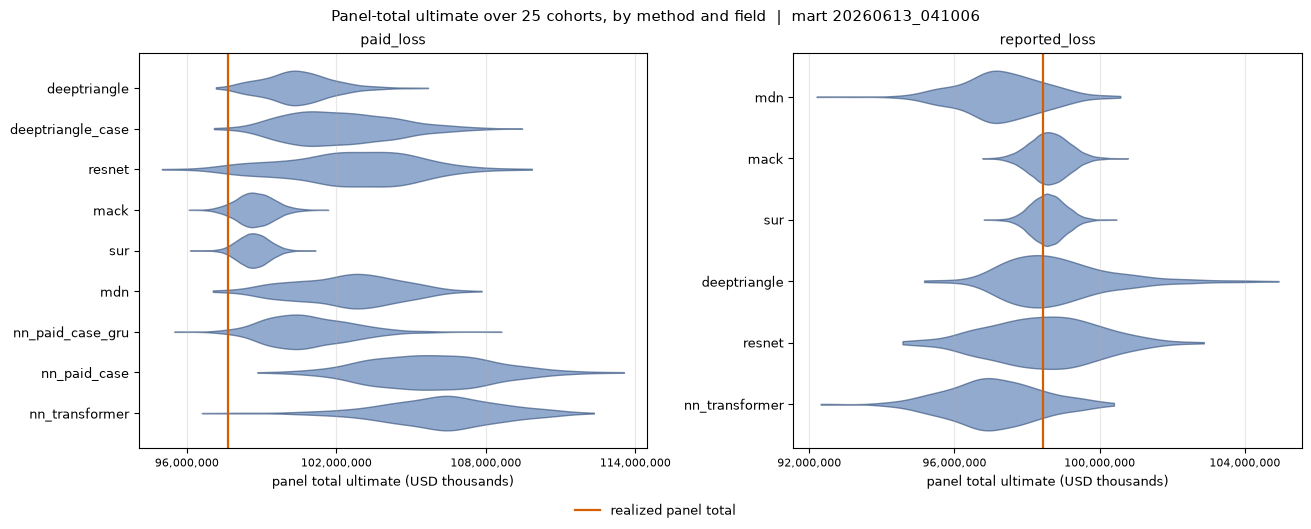

In [26]:
# Panel-total ultimates, from the same draws the table scored.
from matplotlib.lines import Line2D

panel_draws: dict[tuple[str, str], np.ndarray] = {}
for (_model, _field), g in ults.groupby(["model", "field"], sort=False):
    _keys = [
        (_model, _field, k) for k in zip(g["company_code"], g["line_of_business"], strict=True)
    ]
    # A within-draw sum needs the whole panel and one draw axis; anything else would be a
    # different total plotted against the same line.
    if len(_keys) != len(COHORTS) or len({len(ult_draw[k]) for k in _keys}) != 1:
        continue
    panel_draws[(_model, _field)] = np.sum([ult_draw[k] for k in _keys], axis=0)

realized_panel = {}
for _field in ULT_FIELDS:
    _vals = [
        float(g["realized_ultimate"].sum())
        for (m, f), g in ults.groupby(["model", "field"], sort=False)
        if f == _field and (m, f) in panel_draws
    ]
    realized_panel[_field] = float(np.median(_vals))
    print(
        f"{_field:14s} {len(_vals)} methods cover the whole panel and agree about its realized "
        f"total to {max(_vals) / min(_vals) - 1:.1e}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2), layout="constrained")
for ax, _field in zip(axes, ULT_FIELDS, strict=True):
    names = [
        m
        for m in ult_board.loc[ult_board["field"] == _field, "model"]
        if (m, _field) in panel_draws
    ]
    pos = np.arange(len(names))
    parts = ax.violinplot(
        [panel_draws[(m, _field)] for m in names],
        positions=pos,
        orientation="horizontal",
        showextrema=False,
        widths=0.85,
    )
    for body in parts["bodies"]:
        body.set_facecolor("#4c72b0")
        body.set_edgecolor("#2c4a75")
        body.set_alpha(0.6)
    ax.axvline(realized_panel[_field], color="#D55E00", lw=1.6)
    ax.set_yticks(pos, names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(f"panel total ultimate ({tri.meta.units})", fontsize=9)
    ax.set_title(_field, fontsize=10)
    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4))
    ax.xaxis.set_major_formatter(lambda v, _p: f"{v:,.0f}")
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", alpha=0.3)
fig.legend(
    handles=[Line2D([], [], color="#D55E00", lw=1.6, label="realized panel total")],
    loc="outside lower center",
    frameon=False,
    fontsize=9,
)
fig.suptitle(
    f"Panel-total ultimate over {len(COHORTS)} cohorts, by method and field  |  mart {PUBLISH_ID}",
    fontsize=11,
)
plt.show()

Every method over-states the paid ultimate, and none of them is calibrated on that field.
The predicted paid total for the whole panel lands above the realized total for all nine, and
every paid PIT rejects uniformity at the 5% level. Part of that gap is development the study
window cannot see: the realized paid figure at 96 months is cash paid to date, not a settled
amount, so a method that projects past it is not wrong for doing so.

The six methods fitted on incurred all pass there, and their aggregate errors fall to a
fraction of the paid values. Incurred at 96 months already carries the case estimate of
what is left to pay, so the outcome sits inside the range the models produce instead of
beyond it, and the errors fall on both sides of it rather than all on one.

The ranking does not carry across the two fields. `deeptriangle` scores best on paid and
`mdn` best on incurred; only last place is stable, and `nn_transformer` holds it on both.
`mack` and `sur` land next to each other in every column, which is the check the multi-line
section below sets out: at the correlations `sur` estimates, its per-line marginals are the
volume-weighted chain ladder.

The three case-reserve rows do not disturb the top of the paid table. Giving `deeptriangle`
the case-reserve level in place of its reported-loss channel cost it on all three columns:
CRPS 2.23% of premium against 2.08%, a signed error of 3.4% of premium against 2.1%, and a
PIT statistic of 35.8 against 27.8. The
plain entry keeps first place, and its variant takes second. On this panel the case reserve
is the weaker second channel of the two, which is a result about this task and this training
cut - one seed, 120 epochs - rather than about the head that reads it.

The two `nn_paid_case` backbones differ more from each other than either differs from the
entries around it. The GRU arm scores 2.68 against the transformer arm's 3.74, and it
over-states the panel's paid total by 2.4% of premium against 6.2%. The two share their head,
their loss, their data and their rollout, so the encoder is the difference between them, and
the transformer arm ends up beside `nn_transformer` - this notebook's other transformer - at
the bottom of the paid table. Modelling the case reserve jointly with paid loss therefore did
not beat the single-channel entries here, and the gap between its two bodies covers about
two thirds of the range the whole paid column spans.

The figure separates width from position. `mack` and `sur` draw the narrowest distributions
on both fields and still miss the paid line, so a narrow predictive here reports a method's
own variance and not the accuracy of its centre. Width is not the whole story either:
`nn_paid_case`'s paid distribution is one of the widest on the panel and still sits almost
entirely to the right of the realized total, so it is wrong about the location by more than
its own spread covers.


### The drain diagnostic

`nn_paid_case` simulates the case reserve alongside the paid loss, so its rollout carries a
second quantity worth looking at: where the case level ends up. `case_paths()` returns that
terminal level for every draw, cohort and accident year, as a ratio to the origin's earned
premium, off the same cached rollout the ultimates above came from. A case reserve that has
done its job is nearly exhausted by the end of the projection, so the bulk of the mass
belongs near zero; a long positive tail is the model saying development continues past the
window the triangle covers; terminal levels below zero are a defect rather than a finding,
since nothing constrains the sign of the movement the network predicts.

This is a diagnostic and not a board column. The release ships no realized case-reserve
column to score these paths against, so their calibration is unvalidated: what the board
checks is the paid projection they feed, not the paths themselves.

In [27]:
# Terminal simulated case level per (draw, cohort, accident year), as a ratio to premium.
drain_rows = []
for model_name, fitted in paid_case_fits.items():
    # the same (n_draws, seed) the predict() calls above used, so the rollout is cached
    # and these are those draws rather than a second simulation
    terminal = fitted.case_paths(seed=SEED_DRAW).reshape(-1)
    drain_rows.append(
        {
            "model": model_name,
            "backbone": fitted.config_.backbone,
            "values": int(terminal.size),
            "p5": float(np.percentile(terminal, 5)),
            "median": float(np.median(terminal)),
            "p95": float(np.percentile(terminal, 95)),
            "pct_below_zero": 100.0 * float((terminal < 0).mean()),
        }
    )
print("terminal case level as a ratio to the accident year's earned premium")
display(pd.DataFrame(drain_rows).round(4))

terminal case level as a ratio to the accident year's earned premium


,model,backbone,values,p5,median,p95,pct_below_zero
0,nn_paid_case,transformer,100000,-0.1789,0.0006,0.1468,48.272
1,nn_paid_case_gru,gru,100000,-0.0686,0.0064,0.1018,39.327


Both backbones put the median terminal case level within a percent of premium of zero, which
is the drain doing its job. Neither concentrates there. The 5th and 95th percentiles run from
-18% to +15% of premium for the transformer body and from -7% to +10% for the GRU, and 48% of
the transformer's terminal levels and 39% of the GRU's are below zero.

A case reserve below zero is not a position a claims department can be in, so those are the
unconstrained movement head overshooting the drain - the limitation the entry's card records,
at a size worth knowing. It bounds how far these paths can be read as a statement about case
reserves, and it is a reason to prefer the diagnostic reading above to a forecast reading.

## Inside the transformer

Everything above arrived through one call, `gallery.fit(name, triangle, ...)`. For an entry
whose model is a written-out likelihood sitting beside it in the source, that call hides
nothing of substance. The neural entries are not like that: the model is the network, the
training scheme and the rollout, and `fit()` hides all three. This section opens
`nn_transformer` up.

### The problem, and why attention

A loss triangle is a grid, accident year down the rows and development lag across the
columns. Cells on and above the latest diagonal have been observed; the cells below it have
to be predicted.

The chain ladder answers that one column at a time. The age-to-age factor at development step
*j* is estimated from column *j* against column *j+1* and looks at nothing else: not at how
this accident year behaved at 12 months, not at whether calendar year 1994 was adverse across
the whole book, not at the other line of business the same company writes. That is `mack`
(Mack, 1993), the benchmark on the board above, and its virtue is that every one of its
assumptions is written down.

The transformer treats every (origin, dev) cell as a token - the role a word plays in a
language model - and runs self-attention over the whole grid at once. Any cell can then
condition on any other cell: the same column (development), the same row (accident year), the
same diagonal (calendar year), or any combination the data support. None of that is
hard-coded. Position enters as three learned embeddings, and the attention weights decide
what to use.

### What the small data force

A 10x10 Schedule P triangle has 55 observed cells, and the eight accident years this notebook
keeps leave 36 of them per cohort. That is far too few to train an attention model on one
triangle, so two constraints hold for every design choice below:

* the fit is pooled - one network trained across every cohort in the panel at once, which is
  also why the neural rows on the board saw twenty-five triangles where the `mack` row saw
  one;
* the target is an incremental loss ratio - one development step's emergence divided by that
  origin's earned premium - so a $2M book and a $2B book sit on one scale and the network
  never has to reproduce the level of any individual triangle.

The three diagrams below split the entry into its three jobs: preparing the data, one shared
forward pass with the loop that trains it, and inference. Line references point into the
installed package at version 0.5.5, so the code can be read beside the picture.

### 1. Data preparation

`ibnr/kernels/nn_contract.py:197` (`nn_data`) is the only route from a `Triangle` to the
arrays a neural entry consumes. `fit()` calls it on the training slice (`Triangle.as_of`, at
`ibnr/gallery/nn/transformer/model.py:113`), so an unsliced triangle cannot leak the future
in.

Three conventions in the returned contract carry everything downstream:

* **`x` holds incremental loss ratios, not losses.** Cell *(w, d)* is
  `(cumulative[d] - cumulative[d-1]) / premium[w]`. Increments rather than cumulatives,
  because successive cumulative cells are almost perfectly correlated and there is little in
  that for a model to learn; ratios rather than dollars, because that is the cross-cohort
  normalizer.
* **`obs_mask` marks a usable increment, not the presence of a cell.** An increment needs its
  immediate predecessor, so a cell whose predecessor is missing is masked out even though the
  triangle holds it. Absent cells are stored as `x = 0.0`, and that zero is padding rather
  than a claim that the increment was zero.
* **`cal_idx[w, d] = w + d + 1` is calendar time on a dense grid.** Cells sharing a `cal_idx`
  share an evaluation date, which is what makes a valuation date expressible as a single
  integer cutoff. It drives both the validation split and the training augmentation.

Two further steps are shared by every neural entry (`ibnr/gallery/nn/_scheme.py:20-108`).
`splits` holds out the trailing observed calendar
diagonals as validation - validating by evaluation date, the way the model is used, rather
than by a random cell - and `norm_stats` standardizes the target within each development
step, from training-context cells only.

`norm_stats` is where the pinning arises. A development step with fewer than two context
values - in practice the deepest, whose only observations sit on the held-out diagonal - is
pinned: its standardized value is defined as 0, the mean falls back to all observed cells at
that step, and the standard deviation is fixed at 1. That rule replaced an earlier scheme
which inherited an earlier step's statistics, and it moved the mean paid error from +14% to
+4%. Its cost is that a pinned step has no trained head, so the entry declines to report a
density there.

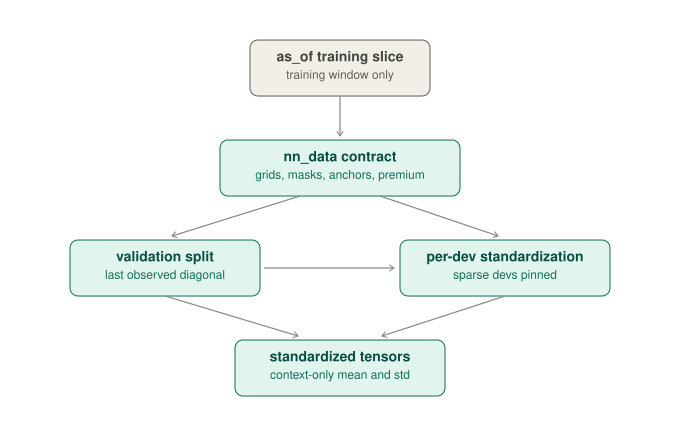

In [28]:
# a Triangle becomes standardized tensors
DAG_DATA_PREP = """<svg width="680" height="440" viewBox="0 0 680 440" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer data preparation</title>
<defs><marker id="dagprep-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<g>
<rect x="250" y="40" width="180" height="56" rx="8" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="1"/>
<text x="340" y="58" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">as_of training slice</text>
<text x="340" y="76" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">training window only</text>
</g>
<line x1="340" y1="96" x2="340" y2="136" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<g>
<rect x="220" y="140" width="240" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="340" y="158" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">nn_data contract</text>
<text x="340" y="176" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">grids, masks, anchors, premium</text>
</g>
<line x1="300" y1="196" x2="172" y2="236" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<line x1="380" y1="196" x2="498" y2="236" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<g>
<rect x="70" y="240" width="190" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="165" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">validation split</text>
<text x="165" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">last observed diagonal</text>
</g>
<g>
<rect x="400" y="240" width="210" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="505" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">per-dev standardization</text>
<text x="505" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">sparse devs pinned</text>
</g>
<line x1="264" y1="268" x2="394" y2="268" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<line x1="165" y1="296" x2="298" y2="336" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<line x1="505" y1="296" x2="382" y2="336" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagprep-arrow)"/>
<g>
<rect x="235" y="340" width="210" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="340" y="358" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">standardized tensors</text>
<text x="340" y="376" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">context-only mean and std</text>
</g>
</svg>"""

display(SVG(DAG_DATA_PREP))

### 2. One shared forward pass, and the loop that trains it

Little of this architecture is specific to a task. One network serves the training loss, the
validation score, the autoregressive rollout and the held-out scorer; the only thing that
changes between them is the pair *(which cells are context, where the cutoff is)*.

The forward pass, in five moves (`ibnr/gallery/nn/transformer/network.py`):

1. **tokens** (`:146-154`) - `x * flag` zeroes every non-context value and the grid is
   flattened to `T = W x D` tokens. The context flag is concatenated as an extra feature,
   which is what lets one network serve both roles: a predicted cell's token still exists and
   still attends, carrying position and conditioning instead of a value.
2. **position** (`:73-80`) - three learned embeddings added per token: origin, development,
   and distance past the conditioning cutoff. The third is the substantive design decision
   here. An absolute calendar embedding is the more obvious choice, but forecasting happens
   on diagonals beyond the training window, where an absolute embedding's rows have received
   no gradient, so earlier versions injected untrained parameters at exactly the cells being
   predicted.
3. **cohort conditioning** (`:162-163`) - the line of business as an 8-dimensional embedding
   plus the cohort's normalized log premium, added to all `T` tokens. There is no company
   embedding: roughly 600 companies with about 55 cells each is a memorization vector rather
   than a feature.
4. **attention** (`:87-96`) - two encoder layers, `d_model` 64, 4 heads, feed-forward width
   128, pre-layer-norm. There is no attention mask; every token attends to every other. The
   masking that matters is on the values, not on the attention. This is the step for which
   the chain ladder has no analogue.
5. **the mixture density head** (`:167-183`) - a mixture weight, mean and scale per cell for
   each of `K = 3` Gaussian components. A lognormal head is unusable here because net-of-bulk
   increments go negative, and a quantile head cannot produce coherent sums while an ultimate
   is a sum of many future cells. A mixture gives a proper density that can be both evaluated
   and sampled, and sampling is what CRPS, the PIT and the rollout require.

The training loop adds three things:

* **calendar-cutoff augmentation** (`model.py:190-203`). In each epoch each cohort is handed
  a synthetic valuation date drawn from inside the training window: condition on cells up to
  that diagonal, score the observed cells after it. One triangle becomes several distinct
  next-diagonal tasks - the principal small-data multiplier, and what supervises the
  distance-past-cutoff embedding at every distance the rollout later asks for.
* **a masked mixture negative log-likelihood** (`network.py:186-205`). The network produces a
  distribution for every cell of every grid; the loss counts only the cells the mask names.
  Changing the mask changes the task without touching the network.
* **a five-member deep ensemble** (`ibnr/gallery/nn/_training.py:97-157`), AdamW with early
  stopping on the validation diagonals. The mixture supplies aleatoric spread, the
  irreducible noise in one cell; the ensemble supplies epistemic spread, disagreement about
  what the network should have been.

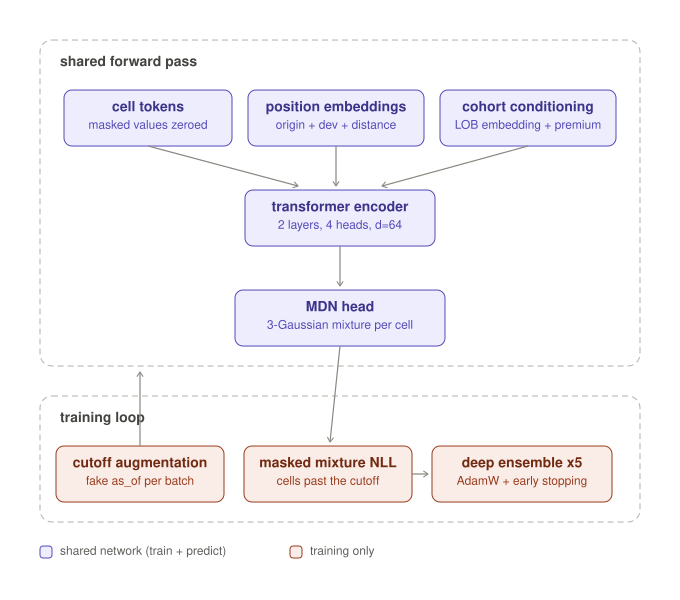

In [29]:
# one network, two callers
DAG_FORWARD_TRAINING = """<svg width="680" height="600" viewBox="0 0 680 600" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer forward pass and training loop</title>
<defs><marker id="dagfwd-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<rect x="40" y="40" width="600" height="326" rx="12" fill="none" stroke="#B4B2A9" stroke-width="1" stroke-dasharray="6 4"/>
<text x="60" y="66" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">shared forward pass</text>
<g>
<rect x="64" y="90" width="168" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="148" y="108" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">cell tokens</text>
<text x="148" y="126" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">masked values zeroed</text>
</g>
<g>
<rect x="248" y="90" width="176" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="336" y="108" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">position embeddings</text>
<text x="336" y="126" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">origin + dev + distance</text>
</g>
<g>
<rect x="440" y="90" width="176" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="528" y="108" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">cohort conditioning</text>
<text x="528" y="126" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">LOB embedding + premium</text>
</g>
<line x1="148" y1="146" x2="298" y2="186" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="336" y1="146" x2="336" y2="186" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="528" y1="146" x2="382" y2="186" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<g>
<rect x="245" y="190" width="190" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="340" y="208" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">transformer encoder</text>
<text x="340" y="226" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">2 layers, 4 heads, d=64</text>
</g>
<line x1="340" y1="246" x2="340" y2="286" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<g>
<rect x="235" y="290" width="210" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="340" y="308" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">MDN head</text>
<text x="340" y="326" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">3-Gaussian mixture per cell</text>
</g>
<rect x="40" y="396" width="600" height="126" rx="12" fill="none" stroke="#B4B2A9" stroke-width="1" stroke-dasharray="6 4"/>
<text x="60" y="422" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">training loop</text>
<g>
<rect x="56" y="446" width="168" height="56" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="140" y="464" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#712B13">cutoff augmentation</text>
<text x="140" y="482" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#993C1D">fake as_of per batch</text>
</g>
<g>
<rect x="244" y="446" width="168" height="56" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="328" y="464" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#712B13">masked mixture NLL</text>
<text x="328" y="482" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#993C1D">cells past the cutoff</text>
</g>
<g>
<rect x="432" y="446" width="180" height="56" rx="8" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="522" y="464" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#712B13">deep ensemble x5</text>
<text x="522" y="482" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#993C1D">AdamW + early stopping</text>
</g>
<line x1="140" y1="446" x2="140" y2="372" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="340" y1="346" x2="330" y2="442" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<line x1="412" y1="474" x2="428" y2="474" stroke="#8A8880" stroke-width="1.2" marker-end="url(#dagfwd-arrow)"/>
<rect x="40" y="546" width="12" height="12" rx="3" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="60" y="552" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">shared network (train + predict)</text>
<rect x="290" y="546" width="12" height="12" rx="3" fill="#FAECE7" stroke="#993C1D" stroke-width="1"/>
<text x="310" y="552" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">training only</text>
</svg>"""

display(SVG(DAG_FORWARD_TRAINING))

### 3. Inference

Scoring one held-out diagonal needs a single forward pass, because that diagonal sits one
step past everything the cohort has observed. An ultimate is different: it is the sum of
every remaining future cell, seven calendar diagonals deep on this panel, and the network has
never been trained to jump that far.

So `predict()` (`ibnr/gallery/nn/transformer/model.py:249-290`) does not jump. It walks
(`:350-457`), one calendar diagonal at a time, which is the transformer's analogue of the
chain ladder recursion: sample every future cell on the next diagonal from its mixture, write
the samples into the grid as if they were data, promote them to context, re-encode the whole
grid, step on. Re-encoding buys two things. The predicted diagonal is always at distance 1
past the context boundary, the relative position the cutoff augmentation supervised most
heavily; and the draws come out jointly coherent across a cohort's cells rather than only
marginally correct, which is what makes a sum over cells - an ultimate, or the cohort-total
PIT tested above - a legitimate object rather than a sum of unrelated marginals.

The last step back to dollars is `latest_cum + premium x (sum of sampled future ratios)`
(`:450-457`), with each ratio un-standardized by its own development step's statistics. The
network is only ever asked for increments, never for the level of the triangle.

Both held-out hooks live at `ibnr/gallery/nn/_heldout.py:353-494`. At the deepest development
lags the standardization is pinned, so the fitted head is untrained there. The entry returns
draws but no usable density: the rollout's convention at a pinned step is the pooled
development mean, effectively a point mass at that step's average ratio. That is a weak prediction,
and its CRPS reflects it; the entry is scored at pinned steps rather than exempted there.

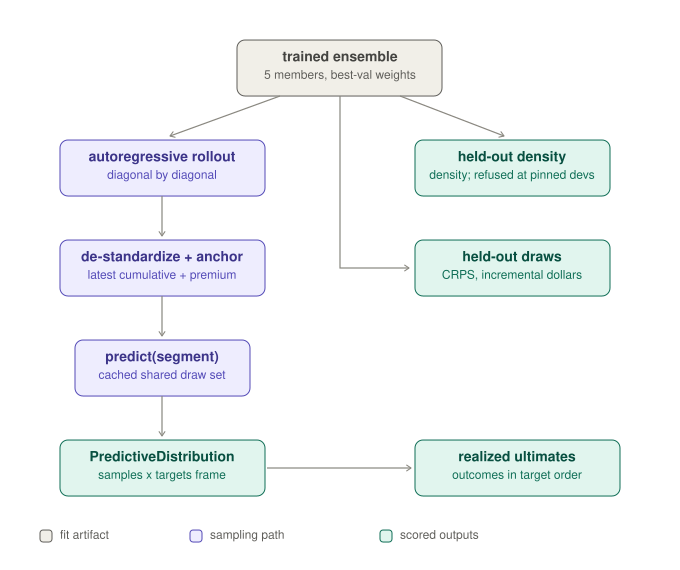

In [30]:
# from trained ensemble to scored outputs
DAG_INFERENCE_OUTPUTS = """<svg width="680" height="570" viewBox="0 0 680 570" xmlns="http://www.w3.org/2000/svg" role="img" style="max-width:100%;height:auto">
<title>nn_transformer inference and outputs</title>
<defs><marker id="daginf-arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="#8A8880" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<g>
<rect x="237" y="40" width="205" height="56" rx="8" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="1"/>
<text x="340" y="58" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#444441">trained ensemble</text>
<text x="340" y="76" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">5 members, best-val weights</text>
</g>
<line x1="280" y1="96" x2="170" y2="136" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<line x1="400" y1="96" x2="504" y2="136" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<path d="M340 96 L340 268 L409 268" fill="none" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="60" y="140" width="205" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="162" y="158" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">autoregressive rollout</text>
<text x="162" y="176" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">diagonal by diagonal</text>
</g>
<g>
<rect x="415" y="140" width="195" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="512" y="158" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">held-out density</text>
<text x="512" y="176" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">density; refused at pinned devs</text>
</g>
<line x1="162" y1="196" x2="162" y2="236" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="60" y="240" width="205" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="162" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">de-standardize + anchor</text>
<text x="162" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">latest cumulative + premium</text>
</g>
<g>
<rect x="415" y="240" width="195" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="512" y="258" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">held-out draws</text>
<text x="512" y="276" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">CRPS, incremental dollars</text>
</g>
<line x1="162" y1="296" x2="162" y2="336" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="75" y="340" width="175" height="56" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="162" y="358" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#3C3489">predict(segment)</text>
<text x="162" y="376" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#534AB7">cached shared draw set</text>
</g>
<line x1="162" y1="396" x2="162" y2="436" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="60" y="440" width="205" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="162" y="458" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">PredictiveDistribution</text>
<text x="162" y="476" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">samples x targets frame</text>
</g>
<line x1="267" y1="468" x2="411" y2="468" stroke="#8A8880" stroke-width="1.2" marker-end="url(#daginf-arrow)"/>
<g>
<rect x="415" y="440" width="205" height="56" rx="8" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="517" y="458" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="14" font-weight="600" fill="#085041">realized ultimates</text>
<text x="517" y="476" text-anchor="middle" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#0F6E56">outcomes in target order</text>
</g>
<rect x="40" y="530" width="12" height="12" rx="3" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="1"/>
<text x="60" y="536" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">fit artifact</text>
<rect x="190" y="530" width="12" height="12" rx="3" fill="#EEEDFE" stroke="#534AB7" stroke-width="1"/>
<text x="210" y="536" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">sampling path</text>
<rect x="380" y="530" width="12" height="12" rx="3" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
<text x="400" y="536" dominant-baseline="central" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5F5E5A">scored outputs</text>
</svg>"""

display(SVG(DAG_INFERENCE_OUTPUTS))

### A live forward pass

The diagrams above are hand-drawn; this cell is not. It builds the same contract `fit()`
builds, constructs an untrained network with the same config the board's fits used, and
reports the shape at every stage of a real forward pass, captured with PyTorch forward hooks
on the live modules, so the shapes are what actually flowed rather than a recomputation. It
also prints the parameter count and the pinned development steps.

Nothing here is trained: it is the architecture, read from the installed package.

In [31]:
import torch

from ibnr.gallery.nn._scheme import norm_stats, splits
from ibnr.gallery.nn.transformer.config import TransformerConfig as TransformerCfg
from ibnr.gallery.nn.transformer.network import TriangleTransformer
from ibnr.kernels.nn_contract import nn_data

# the same call fit() makes, with the arguments the board's NN fits use
nn_contract = nn_data(tri.as_of(AS_OF), loss_field=FIELD, premium_field=PREMIUM_FIELD)
n_c, n_f, n_w, n_d = nn_contract["x"].shape

demo_cfg = TransformerCfg(**NN_CONFIG)
torch.manual_seed(SEED_FIT)
demo_net = TriangleTransformer(
    demo_cfg, n_lob=len(nn_contract["lob_levels"]), n_features=n_f, n_w=n_w, n_d=n_d
).eval()

# the two shared training-scheme pieces from the data-preparation diagram
demo_ctx, demo_val, demo_cutoff = splits(
    nn_contract["obs_mask"], nn_contract["cal_idx"], demo_cfg.val_diagonals
)
# Since 0.5.4 the conditioning mask is PER CHANNEL, so a feature can be absent at a cell
# where the target is observed and is masked there rather than read as the contract's
# padding zero. fit() builds it exactly this way, and channel 0 of x_obs is obs_mask
# itself, which is what leaves a single-channel fit like this one unchanged.
assert (nn_contract["x_obs"][:, 0] == nn_contract["obs_mask"]).all()
demo_ctx_pc = nn_contract["x_obs"] & (nn_contract["cal_idx"] <= demo_cutoff)
demo_mean, demo_std, demo_pinned = norm_stats(nn_contract["x"], demo_ctx_pc, nn_contract["x_obs"])
demo_x = (nn_contract["x"] - demo_mean[None, :, None, :]) / demo_std[None, :, None, :]
demo_x = np.where(demo_pinned[None, :, None, :], 0.0, demo_x)
_pm, _ps = float(np.mean(nn_contract["log_premium"])), float(np.std(nn_contract["log_premium"]))

x_t = torch.tensor(demo_x, dtype=torch.float32)
ctx_t = torch.tensor(demo_ctx_pc)
lob_t = torch.tensor(nn_contract["lob_idx"], dtype=torch.long)
prem_t = torch.tensor((nn_contract["log_premium"] - _pm) / _ps, dtype=torch.float32)
cut_t = torch.full((n_c,), demo_cutoff, dtype=torch.long)

stages = []
hooks = [
    mod.register_forward_hook(
        lambda m, args, out, nm=nm: stages.append(
            {
                "module": nm,
                "type": type(m).__name__,
                "input": str(tuple(args[0].shape)),
                "output": str(tuple(out.shape)),
            }
        )
    )
    for nm, mod in demo_net.named_children()
]
with torch.no_grad():
    demo_log_pi, demo_mu, demo_sigma = demo_net(x_t, ctx_t, lob_t, prem_t, cut_t)
for h in hooks:
    h.remove()

print(
    f"B = {n_c} cohorts, F = {n_f} channels, W = {n_w} origins, D = {n_d} devs, "
    f"T = {n_w * n_d} tokens, d_model = {demo_cfg.d_model}, K = {demo_cfg.n_components}"
)
display(pd.DataFrame(stages))
_wsum = demo_log_pi.exp().sum(-1)
print("returned log_pi / mu / sigma:", tuple(demo_log_pi.shape), "= (B, W, D, K)")
print(f"mixture weights sum to 1 everywhere: min {_wsum.min():.6f}, max {_wsum.max():.6f}")
print(f"per-cell distributions from this one forward pass: {demo_mu[..., 0].numel():,}")
print()

total_params = sum(p.numel() for p in demo_net.parameters())
encoder_params = sum(p.numel() for p in demo_net.encoder.parameters())
print(f"parameters: {total_params:,} total, {encoder_params:,} of them the two encoder layers")
print(f"training-context cells across the whole panel: {int(demo_ctx.sum()):,}")
print(f"validation cells held out by calendar date:    {int(demo_val.sum()):,}")
print(f"parameters per training-context cell:          {total_params / demo_ctx.sum():.0f}")
print()

_devs = [(d + 1) * nn_contract["dev_grain_months"] for d in range(n_d)]
display(
    pd.DataFrame(
        {
            "dev_lag": _devs,
            "context cells": [int(demo_ctx[:, :, d].sum()) for d in range(n_d)],
            "mean ratio": demo_mean[0],
            "sd ratio": demo_std[0],
            "pinned": demo_pinned[0],
        }
    ).round(5)
)
print(
    "The pinned row(s) are the deepest development step(s): their only observations sit on\n"
    "the held-out validation diagonal, so no training-context value reaches the normalizer,\n"
    "the head there is untrained, sd is fixed at 1 and the standardized value is defined\n"
    "as 0. Those are the steps at which the entry reports no held-out density."
)

B = 25 cohorts, F = 1 channels, W = 8 origins, D = 8 devs, T = 64 tokens, d_model = 64, K = 3


,module,type,input,output
0,value_proj,Linear,"(25, 64, 2)","(25, 64, 64)"
1,origin_emb,Embedding,"(64,)","(64, 64)"
2,dev_emb,Embedding,"(64,)","(64, 64)"
3,dist_emb,Embedding,"(25, 64)","(25, 64, 64)"
4,lob_emb,Embedding,"(25,)","(25, 8)"
5,cond_proj,Linear,"(25, 9)","(25, 64)"
6,drop,Dropout,"(25, 64, 64)","(25, 64, 64)"
7,encoder,TransformerEncoder,"(25, 64, 64)","(25, 64, 64)"
8,out_norm,LayerNorm,"(25, 64, 64)","(25, 64, 64)"
9,head,Linear,"(25, 64, 64)","(25, 64, 9)"


returned log_pi / mu / sigma: (25, 8, 8, 3) = (B, W, D, K)
mixture weights sum to 1 everywhere: min 1.000000, max 1.000000
per-cell distributions from this one forward pass: 1,600

parameters: 70,121 total, 66,944 of them the two encoder layers
training-context cells across the whole panel: 700
validation cells held out by calendar date:    200
parameters per training-context cell:          100



,dev_lag,context cells,mean ratio,sd ratio,pinned
0,12,175,0.19279,0.09674,False
1,24,150,0.17970,0.06523,False
2,36,125,0.11968,0.05518,False
3,48,100,0.08530,0.04918,False
4,60,75,0.05072,0.04129,False
5,72,50,0.03776,0.03830,False
6,84,25,0.01851,0.03113,False
7,96,0,0.00829,1.00000,True


The pinned row(s) are the deepest development step(s): their only observations sit on
the held-out validation diagonal, so no training-context value reaches the normalizer,
the head there is untrained, sd is fixed at 1 and the standardized value is defined
as 0. Those are the steps at which the entry reports no held-out density.


## Multi-line dependence

Every entry on the board above models one triangle at a time. The pooled neural entries do
too: they are trained across cohorts, but their per-cohort draws are independent, so a
company's commercial auto and workers compensation reserves come out of two unrelated
sampling paths. Adding those two ultimates together assumes independence, which no reserving
department believes.

`sur` - Zhang's (2010) seemingly-unrelated-regressions multivariate chain ladder, fitted by
feasible generalized least squares - is the entry that relaxes it. One fit per company, over
that company's screened lines, with a contemporaneous cross-line correlation estimated from
the residuals. At zero correlation it collapses to the volume-weighted chain ladder per line,
which is the check worth knowing before reading the correlations it reports.

`sur` subclasses neither held-out mixin, as the roster cell shows, so it has no board row at
all. The comparison therefore happens at the ultimate level, where every entry produces a
number:

* each board entry's company total is the sum of its per-line total ultimates, summed within
  a draw, which is the independence assumption written out;
* `sur`'s company total comes from its own joint predictive.

The PIT of a company's realized total is then one observation per company for every model
here - n = 10, the same n, directly comparable - and the difference between the sums and the
joint is the quantity in question.

Two omissions. `copula_glm` is the gallery's other cross-line entry, and it is left out to
keep this appendix to one comparison. `nn_transformer_ml`, the multi-line transformer, is
omitted on cost: its rollout samples line by line per calendar diagonal, and a single pooled
fit on this ten-company panel ran past ten minutes without completing when that was measured.
That is the one figure in this notebook quoted from a separate measurement rather than from
its own timing table.

In [32]:
ml_rows, corr_rows, ml_failures = [], [], []
ml_draws: dict[str, np.ndarray] = {}
t0 = time.perf_counter()
for company, lines in PANEL.items():
    ce = tri.expr
    ctri = tri.filter(ce.company_code == company)
    try:
        entry = gallery.fit("sur", ctri, loss_field=FIELD, as_of=AS_OF)
    except Exception as exc:
        # sur's FGLS has documented family limits (it whitens by 1/sqrt(C), so a
        # non-positive cumulative cell is refused); a refusal is a result, not a crash.
        ml_failures.append(dict(model="sur", company_code=company, error=repr(exc)[:180]))
        continue
    pred = entry.predict(seed=SEED_DRAW)
    outcome = np.asarray(entry.realized_ultimates(ctri), dtype=float)
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    ml_draws[company] = np.asarray(pred.samples[:, i], dtype=float)
    ml_rows.append(
        dict(
            model="sur",
            company_code=company,
            n_lines=len(lines),
            predicted_total=float(pred.mean()[i]),
            sd=float(pred.std()[i]),
            realized_total=outcome[i],
            pct_error=100.0 * (pred.mean()[i] - outcome[i]) / outcome[i],
            outcome_pct=100.0 * float(pred.cdf(outcome)[i]),
        )
    )
    # The quantity the single-line entries cannot produce.
    corr = entry.pooled_corr_
    off = corr[np.triu_indices_from(corr, k=1)]
    corr_rows.append(
        dict(
            company_code=company,
            n_lines=len(lines),
            mean_cross_line_corr=float(np.mean(off)),
            max_abs=float(np.max(np.abs(off))),
        )
    )
    del entry
print(f"{len(ml_rows)} sur fits in {time.perf_counter() - t0:.1f}s; {len(ml_failures)} refusals")
for f in ml_failures:
    print("  ", f)
display(pd.DataFrame(ml_rows).round(2))
print("estimated contemporaneous cross-line correlation, per company:")
display(pd.DataFrame(corr_rows).round(3))

10 sur fits in 3.0s; 0 refusals


,model,company_code,n_lines,predicted_total,sd,realized_total,pct_error,outcome_pct
0,sur,10022,2,53498.57,1292.97,52346.0,2.20,18.95
1,sur,14044,3,37593.87,641.78,37281.0,0.84,31.86
2,sur,1767,4,82536284.52,581936.63,81660998.0,1.07,6.35
3,sur,18767,2,223047.28,3232.82,210677.0,5.87,0.00
4,sur,2003,2,10789869.88,171792.36,10707190.0,0.77,32.13
5,sur,25275,2,83763.15,1166.65,88574.0,-5.43,100.00
6,sur,27022,2,56989.34,1095.31,54062.0,5.41,0.30
7,sur,2712,2,767278.34,8948.42,719725.0,6.61,0.00
8,sur,620,3,1109220.58,18485.87,1118853.0,-0.86,70.43
9,sur,7080,3,3018501.53,24661.16,2982600.0,1.20,7.27


estimated contemporaneous cross-line correlation, per company:


,company_code,n_lines,mean_cross_line_corr,max_abs
0,10022,2,0.317,0.317
1,14044,3,-0.053,0.341
2,1767,4,0.444,0.824
3,18767,2,-0.012,0.012
4,2003,2,0.381,0.381
5,25275,2,-0.362,0.362
6,27022,2,0.000,0.000
7,2712,2,0.165,0.165
8,620,3,-0.002,0.109
9,7080,3,0.027,0.147


In [33]:
# Company totals for every model on one footing.
#   board entries: sum a company's per-line total-ultimate draws WITHIN a draw, which
#                  is the independence assumption written out;
#   sur:           its own joint predictive of the company total.
_realized = points.set_index(["model", "company_code", "line_of_business"])["realized_ultimate"]
company_rows = []
for model in sorted({k[0] for k in ultimate_draws}):
    for company, lines in PANEL.items():
        keys = [(model, (company, ln)) for ln in lines]
        if not all(k in ultimate_draws for k in keys):
            continue  # this model did not produce an ultimate for every line
        if len({len(ultimate_draws[k]) for k in keys}) != 1:
            continue  # draw counts differ, so a within-draw sum is not defined
        draws = np.sum([ultimate_draws[k] for k in keys], axis=0)
        realized = float(sum(_realized.loc[(model, company, ln)] for ln in lines))
        premium = float(sum(PREMIUM_TOTAL[(company, ln)] for ln in lines))
        company_rows.append(
            dict(
                model=model,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(draws.mean()),
                sd=float(draws.std(ddof=1)),
                realized_total=realized,
                pct_error=100.0 * (draws.mean() - realized) / realized,
                error_pct_premium=100.0 * (draws.mean() - realized) / premium,
                outcome_pct=100.0 * float((draws <= realized).mean()),
            )
        )
for row in ml_rows:
    company = row["company_code"]
    premium = float(sum(PREMIUM_TOTAL[(company, ln)] for ln in PANEL[company]))
    err = row["predicted_total"] - row["realized_total"]
    company_rows.append({**row, "error_pct_premium": 100.0 * err / premium})
ult = pd.DataFrame(company_rows)

# The realized total is a property of the data, not of the model, so every model that
# covered a company should agree on it. Printed rather than asserted: sur restricts
# origins its own way, and a disagreement is worth seeing rather than crashing on.
_spread = ult.groupby("company_code")["realized_total"].agg(lambda s: s.max() / s.min() - 1.0)
print(f"max relative disagreement about a company's realized total: {_spread.max():.2e}")

ult_summary = (
    ult.groupby("model")
    .agg(
        companies=("company_code", "nunique"),
        median_pct_error=("pct_error", "median"),
        mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
        mean_abs_error_pct_premium=("error_pct_premium", lambda s: s.abs().mean()),
        median_outcome_pct=("outcome_pct", "median"),
    )
    .sort_values("mean_abs_error_pct_premium")
)
print(
    "\nCompany-total ultimates. mean_abs_error_pct_premium is the premium-normalized\n"
    "reserve error - the metric that survives a panel spanning four orders of magnitude\n"
    "of premium, where a percentage-of-ultimate error does not."
)
display(ult_summary.round(2))
display(ult.pivot_table(index="company_code", columns="model", values="pct_error").round(1))

max relative disagreement about a company's realized total: 0.00e+00

Company-total ultimates. mean_abs_error_pct_premium is the premium-normalized
reserve error - the metric that survives a panel spanning four orders of magnitude
of premium, where a percentage-of-ultimate error does not.


,companies,median_pct_error,mean_abs_pct_error,mean_abs_error_pct_premium,median_outcome_pct
model,,,,,
deeptriangle,10,2.04,3.08,2.08,18.70
sur,10,1.14,3.03,2.12,13.11
mack,10,1.19,3.04,2.12,13.60
resnet,10,4.83,4.51,3.07,7.40
mdn,10,5.82,4.80,3.32,1.00
nn_transformer,10,5.51,6.44,4.39,5.40


model,deeptriangle,mack,mdn,nn_transformer,resnet,sur
company_code,,,,,,
10022,4.0,2.1,7.3,7.1,4.5,2.2
14044,6.9,0.8,8.4,14.6,9.5,0.8
1767,3.2,1.1,4.9,9.4,5.5,1.1
18767,5.8,5.9,8.9,8.7,10.2,5.9
2003,2.0,0.8,7.0,10.4,5.1,0.8
25275,-2.9,-5.5,0.6,1.1,-1.9,-5.4
27022,1.8,5.4,6.8,3.9,5.4,5.4
2712,2.0,6.6,1.4,-1.2,0.7,6.6
620,-1.7,-0.8,-2.3,-3.1,-1.1,-0.9


n = [10] companies per model. At this n the KS test detects only gross
miscalibration, so read the mean PIT column at least as hard as the statistic:
a mean well below 0.5 says the realized total lands in the lower tail of the
predictive far more often than it should, i.e. the predictives are biased high
relative to their own spread.


,model,n_companies,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,deeptriangle,10,43.80,43.007,0.043,False,0.271
1,mack,10,45.77,43.007,0.030,False,0.269
2,sur,10,47.87,43.007,0.020,False,0.267
3,nn_transformer,10,49.80,43.007,0.014,False,0.313
4,resnet,10,51.00,43.007,0.011,False,0.252
5,mdn,10,58.40,43.007,0.002,False,0.201


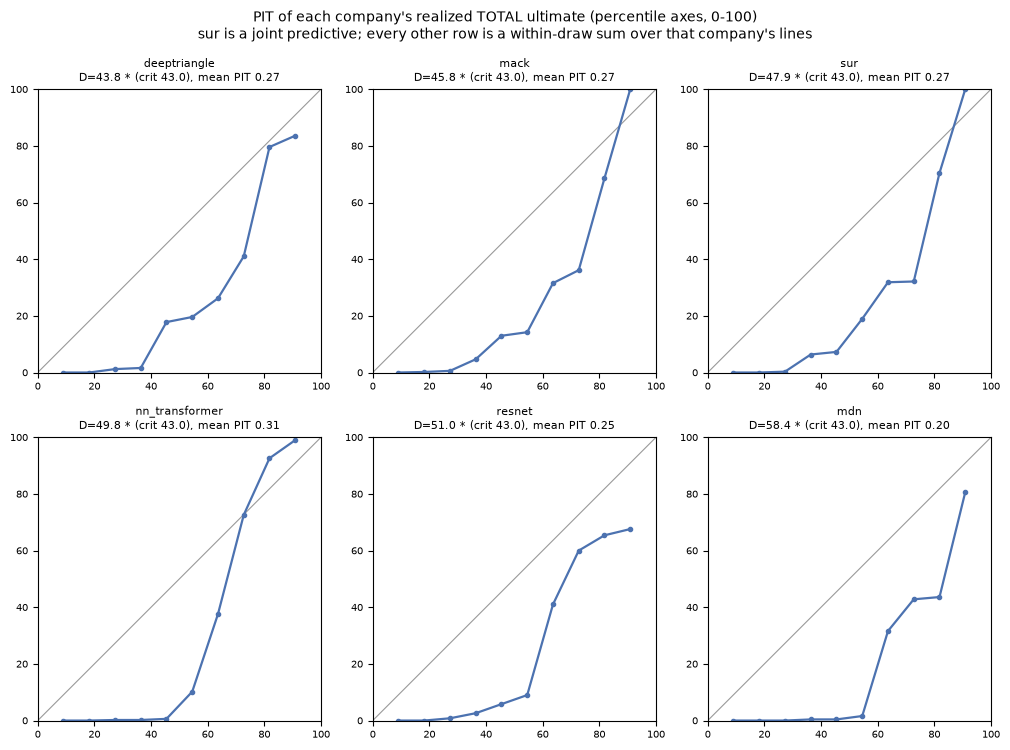

In [34]:
# Calibration at the company level: one PIT per company for every model, same n.
ks_ult = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_companies": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["outcome_pct"].mean() / 100.0),
            }
            for m, g in ult.groupby("model")
            for r in [ks_uniformity(g["outcome_pct"].to_numpy() / 100.0)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
_ns = sorted(set(ks_ult["n_companies"]))
print(
    f"n = {_ns} companies per model. At this n the KS test detects only gross\n"
    "miscalibration, so read the mean PIT column at least as hard as the statistic:\n"
    "a mean well below 0.5 says the realized total lands in the lower tail of the\n"
    "predictive far more often than it should, i.e. the predictives are biased high\n"
    "relative to their own spread."
)
display(ks_ult.round(3))

_models = ks_ult["model"].tolist()
ncol = min(3, len(_models))
nrow = int(np.ceil(len(_models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.8 * nrow), squeeze=False)
_ku = ks_ult.set_index("model")
for ax, m in zip(axes.ravel(), _models):
    p = ult.loc[ult["model"] == m, "outcome_pct"].to_numpy() / 100.0
    x, y = pp_points(p)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, marker="o", ms=3, color="#4c72b0")
    rc = _ku.loc[m]
    ax.set_title(
        f"{m}\nD={rc['D x 100']:.1f}{'' if rc['passes'] else ' *'} "
        f"(crit {rc['critical 5% x 100']:.1f}), mean PIT {rc['mean_pit']:.2f}",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(_models) :]:
    ax.axis("off")
fig.suptitle(
    "PIT of each company's realized TOTAL ultimate (percentile axes, 0-100)\n"
    "sur is a joint predictive; every other row is a within-draw sum over that "
    "company's lines",
    fontsize=10,
)
fig.tight_layout()
plt.show()

## Limitations

1. **This is a demonstration, not a study.** Ten companies, twenty-five cohorts, 175
   held-out cells, one cutoff, one field. Rankings on a panel this small move with the panel.
2. **The cohorts are not a random sample of the mart.** They passed the Meyers stability
   screens and were then restricted to companies with no negative paid increment anywhere in
   the training slice. Well-behaved data flatter every model here, and flatter the models
   with the strongest positivity assumptions most.
3. **The neural entries run at a reduced budget.** 120 epochs and 5 ensemble members, against
   the 400 epochs of the published configuration.
4. **The ultimate-level draw counts differ, although the board's do not.** Every held-out
   row rests on 10,000 draws. `predict()`, which the two ultimate-level sections use, takes
   its count from each entry's own configuration: 10,000 for `mack` and `sur`, and
   `NN_CONFIG`'s rollout budget for the four neural entries, because a rollout re-runs the
   network once per future calendar diagonal while a held-out diagonal is a single forward
   pass. Sample CRPS carries an upward bias of order 1/n_draws, so the neural rows of the
   ultimates table pay it. It does not reverse a large gap, and it can decide a small one.
5. **The neural rows did not see the same information as the row they are ranked against.**
   The four neural entries are fitted once, pooled over all twenty-five cohorts; `mack` is
   fitted on a single cohort's triangle, twenty-five times. Each neural row therefore reaches
   its board position having seen roughly twenty-five times the loss history of the row
   beside it. That is how these architectures are intended to be used - one Schedule P
   triangle is far too small to train one - but it makes this board an
   asymmetric-information comparison rather than a like-for-like one, and no panel object can
   correct for it.
6. **No held-out density is reported.** `mack` has none to give, and the neural entries
   decline one wherever the deepest scored cell falls on a pinned development step, which on
   this design is every cohort. That absence is a property of the held-out design rather than
   a verdict on the neural densities.
7. **The KS statistics are weak or descriptive throughout.** The cell-level statistics have
   no valid critical value, because the cells are not independent. The cohort-level test has
   one observation per cohort, but cohorts of one company remain correlated, and the
   company-level test in the appendix has n = 10. All three detect gross miscalibration and
   nothing finer.
8. **The study window is eight accident years, 1990-1997, and that is a choice.** The
   triangle is cut to them before any fit, so the board loses the two deepest development
   lags, where a growth-curve model would be most distinctive. The window is not a
   scoring-only restriction: cutting it into the data is what makes
   `HoldoutCells.train_origins` a true statement about every fit.

In [35]:
import torch  # noqa: F811  (re-imported so this cell stands alone if run on its own)

# Both fields: fit_seconds holds the board's paid fits, ult_seconds the ultimates
# section's, so the total below is every fit the notebook ran.
timings = (
    pd.DataFrame(
        [
            {
                "entry": k,
                "field": FIELD,
                "seconds": v,
                "seconds_per_cohort": round(v / len(COHORTS), 2),
            }
            for k, v in fit_seconds.items()
        ]
        + [
            {
                "entry": k,
                "field": f,
                "seconds": v,
                "seconds_per_cohort": round(v / len(COHORTS), 2),
            }
            for (k, f), v in ult_seconds.items()
        ]
    )
    .sort_values(["field", "seconds"], ascending=[True, False])
    .reset_index(drop=True)
)
display(timings)
print(f"total fitting:   {timings['seconds'].sum() / 60:.1f} min")
print(f"notebook so far: {(time.perf_counter() - T_START) / 60:.1f} min wall clock")
print()
print("mart publish_id ", PUBLISH_ID)
print("panel           ", f"{len(PANEL)} companies, {len(COHORTS)} cohorts")
print("CRPS fingerprint", panel.crps_fingerprint, "|", panel.n_cells_for("crps"), "cells")
print("ibnr            ", ibnr.__version__)
print("cas-schedule-p  ", cas_schedule_p.__version__, "| publish", cas_schedule_p.PUBLISH_ID)
print("python          ", sys.version.split()[0])
print("platform        ", platform.platform())
print("numpy/pandas    ", np.__version__, pd.__version__)
print("torch           ", torch.__version__)

,entry,field,seconds,seconds_per_cohort
0,nn_transformer,paid_loss,68.1,2.72
1,nn_paid_case,paid_loss,51.8,2.07
2,nn_paid_case_gru,paid_loss,35.4,1.42
3,deeptriangle_case,paid_loss,30.6,1.22
4,deeptriangle,paid_loss,29.1,1.16
5,resnet,paid_loss,28.6,1.14
6,mdn,paid_loss,13.7,0.55
7,mack,paid_loss,5.3,0.21
8,sur,paid_loss,2.7,0.11
9,nn_transformer,reported_loss,40.1,1.60


total fitting:   6.4 min
notebook so far: 6.9 min wall clock

mart publish_id  20260613_041006
panel            10 companies, 25 cohorts
CRPS fingerprint bca75d8a6a13005c | 175 cells
ibnr             0.5.5
cas-schedule-p   2026.6.13 | publish 20260613_041006
python           3.12.13
platform         Windows-11-10.0.26200-SP0
numpy/pandas     2.5.1 3.0.5
torch            2.13.0+cpu
